In [1]:
import os
import jax

from jax import numpy as np, random as jr

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# from optim_funcs import sgd, adam
from dLux import utils as dlu


# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots


# import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 250
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

/Users/mc/miniconda3/envs/ami/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    path = "/media/morgana1/snert/max/"
    save_path = path + "data/dorito_figs"
elif (
    gethostname() == "maxs-mbp-14.research.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    path = "/Volumes/morgana1/snert/max/"
    # save_path = "/Users/mc/data/dorito_figs"
    save_path = path + "data/dorito_figs"

else:
    path = "/fred/oz440/max/"

amigo_cache = os.path.join(path, "data/amigo_files/")


def load_fits(source_name):
    if source_name == "NGC1068":
        data_path = os.path.join(path, f"data/JWST/{source_name}/new_calslope/")
    else:
        data_path = os.path.join(path, f"data/JWST/{source_name}/calslope/")
    uncal_path = os.path.join(path, f"data/JWST/{source_name}/uncal/")
    amigo_cache = os.path.join(path, "data/amigo_files/")

    cache = os.path.join(amigo_cache, "v_0.0.10/")
    output_path = os.path.join(amigo_cache, f"outputs/{source_name}/")

    EXP_TYPE = "NIS_AMI"
    FILTERS = [
        "F480M",
        "F430M",
        "F380M",
        # "F277W",
    ]

    # Bind file path, type and exposure type
    file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
        data_path,
        "calslope",
        EXP_TYPE=EXP_TYPE,
        FILTER=filters,
        **kwargs,
    )

    files = sorted(
        file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
    )
    sci_files = []
    cal_files = []

    for file in files:

        # manual bad pixel correction
        file["BADPIX"].data[58, 67] = 1
        file["BADPIX"].data[71, 22] = 1
        file["BADPIX"].data[65, 41] = 1
        file["BADPIX"].data[35, 70] = 1
        file["BADPIX"].data[70, 55] = 1
        file["BADPIX"].data[5, 5] = 1
        file["BADPIX"].data[-4, 37] = 1
        file["BADPIX"].data[51, 27] = 1
        file["BADPIX"].data[28, 18] = 1
        file["BADPIX"].data[32, 10] = 1

        file["BADPIX"].data[:, :3] = 1
        file["BADPIX"].data[:, -3:] = 1
        file["BADPIX"].data[:3, :] = 1
        file["BADPIX"].data[-3:, :] = 1

        if file[0].header["TARGPROP"] == "TD-PDS-70":
            file["BADPIX"].data[:66, :25] = 1  # BACKGROUND STAR?
            file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
            file["BADPIX"].data[17, 70] = 1
            file["BADPIX"].data[19, 53] = 1
            file["BADPIX"].data[5, 22] = 1
            file["BADPIX"].data[19, 41] = 1
            file["BADPIX"].data[76, 45] = 1
            file["BADPIX"].data[59, 30] = 1

        if not bool(file[0].header["IS_PSF"]):
            sci_files.append(file)
        elif bool(file[0].header["IS_PSF"]):
            cal_files.append(file)
        else:
            print(f"Unkown target: {file[0].header['TARGPROP']}")
    return sci_files, cal_files


io_sci_files, io_cal_files = load_fits("IO")
ngc_sci_files, ngc_cal_files = load_fits("NGC1068")
wr137_sci_files, wr137_cal_files = load_fits("WR137")

In [3]:
print("ngc1068")
ngc_cal_fits = [
    amigo.model_fits.PointFit(file)
    for file in ngc_cal_files
    if file[0].header["FILTER"] == "F480M"
]
ngc_sci_fits = [
    amigo.model_fits.PointFit(file)
    for file in ngc_sci_files
    if file[0].header["FILTER"] == "F480M"
]

print("io")
io_sci_fits = [
    amigo.model_fits.PointFit(file)
    for file in io_sci_files
    if file[0].header["FILTER"] == "F430M"
]

io_cal_fits = [
    amigo.model_fits.PointFit(file)
    for file in io_cal_files
    if file[0].header["FILTER"] == "F430M"
]

print("wr137")
wr137_sci_fits = [
    amigo.model_fits.PointFit(file)
    for file in wr137_sci_files
    if file[0].header["FILTER"] == "F380M"
]
wr137_cal_fits = [
    amigo.model_fits.PointFit(file)
    for file in wr137_cal_files
    if file[0].header["FILTER"] == "F380M"
]

ngc1068
io
wr137


In [4]:
import planetmapper
import scipy
import numpy

features = {
    "seth": (132, -5.3),  # long [deg], lat [deg]
    "P197": (108.8, -47.3),
    "masubi": (52.6, -45),
    "leizi": (44.93, 13.48),
    # "leizi": (-315.074, 13.48),
    "amirani": (115.2, 24.0),
    # "subobs": (--107.57361768, 2.60587485),
}
# https://iopscience.iop.org/article/10.3847/PSJ/ad4346/pdf


from dorito.plotting import get_arcsec_extents


def plot_result(
    ax,
    array,
    pixel_scale,
    roll_angle_degrees: float = None,
    cmap: str = "afmhot_10u",
    bg_color: str = "k",
    axis_labels: dict = {
        "xlabel": r"$\Delta$RA [arcsec]",
        "ylabel": r"$\Delta$DEC [arcsec]",
    },
    norm=mpl.colors.PowerNorm(1, vmin=0, vmax=None),
    diff_lim: float = None,
    scale=1.0,
    translate=(0.0, 0.0),
    ticks=[0.5, 0, -0.5],
    **other_kwargs,
):

    ax.set_facecolor(bg_color)  # Set the background colour
    ax.tick_params(direction="out")
    ax.set(
        xticks=ticks,
        yticks=ticks[::-1],
        **axis_labels,
    )  # Set the axis labels

    kwargs = {
        "cmap": cmap,
        "extent": get_arcsec_extents(pixel_scale / scale, array.shape),
        "norm": norm,
        # "aspect": "equal",
    }

    im = ax.imshow(
        array,
        **kwargs,
        **other_kwargs,
    )

    if diff_lim is not None:

        centre = 0.95 * np.array(kwargs["extent"][0:2]) + np.array(
            [-diff_lim, diff_lim]
        )

        beam = mpl.patches.Circle(
            centre,
            radius=diff_lim,
            facecolor="white",
            edgecolor="black",
            alpha=0.7,
            zorder=10,
        )
        ax.add_patch(beam)

    if roll_angle_degrees is not None or scale is not None:

        if scale is None:
            scale = 1.0
        if roll_angle_degrees is None:
            roll_angle_degrees = 0.0

        rotation_transform = (
            mpl.transforms.Affine2D()
            .rotate_deg(roll_angle_degrees)
            .scale(scale)
            .translate(*translate)
        )  # Create a rotation transformation
        trans_data = rotation_transform + ax.transData  # creating transformation
        im.set_transform(trans_data)  # applying transformation to image

    return im


def plot_io_with_ephemeris(
    ax, array, exp, data_dir, legend=False, points=None, **kwargs
):

    body = planetmapper.Observation(data_dir + exp.filename + "_uncal.fits")
    if points is not None:
        body.coordinates_of_interest_lonlat = points

    def coordinate_func(ra, dec):
        x, y = body.radec2angular(ra, dec)
        return -x, y

    body.plot_wireframe_custom(
        # body.plot_wireframe_angular(
        ax,
        coordinate_func=coordinate_func,
        # aspect_adjustable="box",
        add_title=False,
        label_poles=True,
        indicate_equator=True,
        indicate_prime_meridian=True,
        grid_interval=30,
        grid_lat_limit=75,
        formatting={
            # "limb": {
            #     "linestyle": "--",
            #     "linewidth": 0.8,
            #     "alpha": 0.8,
            #     "color": "white",
            # },
            "grid": {
                "linestyle": "--",
                "linewidth": 0.5,
                "alpha": 0.3,
                "color": "k",
            },
            "equator": {
                "color": "r",
                "linewidth": 1,
                "color": "r",
                "label": "equator",
                # "alpha": 0.0,
            },
            "terminator": {
                "linewidth": 1,
                "linestyle": "-",
                "color": "aqua",
                "alpha": 0.0,
                "label": "terminator",
            },
            "coordinate_of_interest_lonlat": {
                "color": "gold",
                "marker": "^",
                "facecolors": "none",
                # "markeredgecolor": "red",
                "s": 10,
                "label": "volcano",
            },
            "limb_illuminated": {"color": "b", "alpha": 0.0},
        },
    )

    if legend:
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(
            by_label.values(),
            by_label.keys(),
            loc="upper left",
        )

    im = dorito.plotting.plot_result(
        ax,
        array,
        **kwargs,
    )

    return im


def plot_diffraction_limit(model, ax=None, OOP=False):
    effective_wl = np.dot(
        model.source_spectrum.wavelengths, model.source_spectrum.weights
    )
    diff_lim = dlu.rad2arcsec(effective_wl / model.optics.diameter)
    scale_length = diff_lim

    scale_bar_x = -0.7
    scale_bar_y = scale_bar_x
    fontdict = {
        "fontstyle": "normal",
        "color": "hotpink",
        "weight": "demi",
        "size": 7,
    }

    if OOP and ax is not None:
        ax.plot(
            [scale_bar_x, scale_bar_x + scale_length],
            [scale_bar_y, scale_bar_y],
            color="hotpink",
            linewidth=2,
        )
        ax.text(
            scale_bar_x + scale_length / 2 - 0.075,
            scale_bar_y + 0.03,
            r"$\lambda / D$",
            **fontdict,
        )
        return ax

    else:
        plt.plot(
            [scale_bar_x, scale_bar_x + scale_length],
            [scale_bar_y, scale_bar_y],
            color="hotpink",
            linewidth=2,
        )
        plt.text(
            scale_bar_x + scale_length / 2 - 0.046,
            scale_bar_y + 0.02,
            r"$\lambda / D$",
            **fontdict,
        )


def compute_com_physical(array, pixel_scale):
    """
    Compute the center of mass of a 2D array, assuming the center of the array is at (0, 0).

    Parameters:
    - array: 2D numpy array representing the mass distribution.
    - pixel_scale: The physical scale of each pixel (e.g., in units per pixel).

    Returns:
    - com_physical: The center of mass in physical coordinates, assuming (0, 0) at the center of the array.
    """
    # Compute the center of mass in pixel indices
    com_index = np.array(scipy.ndimage.center_of_mass(numpy.array(array)))

    # Calculate the center of the array in pixel indices
    array_center = np.array(array.shape) / 2 - 0.5  # (rows/2 - 0.5, cols/2 - 0.5)

    # Convert to physical coordinates
    com_physical = (com_index - array_center) * pixel_scale

    return np.array(
        [-com_physical[1], com_physical[0]]
    )  # Return (x, y) in physical coordinates


from PIL import Image


def create_gif_from_dir(png_dir, name, loop=0, **kwargs):
    """
    Create an animated GIF from all PNG files in the specified directory.

    Args:
        png_dir (str): Path to the directory containing PNG files.
        name (str): Name of the output GIF file.
    """
    # Get a sorted list of all PNG files in the directory
    png_files = sorted([f for f in os.listdir(png_dir) if f.endswith(".png")])

    # Ensure there are PNG files to process
    if not png_files:
        raise ValueError("No PNG files found in the directory!")

    # Load the images into a list
    images = [Image.open(os.path.join(png_dir, file)) for file in png_files]

    # Save the images as an animated GIF
    images[0].save(
        png_dir + name,
        save_all=True,
        append_images=images[1:],
        optimize=False,
        loop=loop,
        **kwargs,
    )


def get_arcsec_extents(pixel_scale, shape):
    """
    Get the arcsec extents of an image given the pixel scale and shape.
    """
    return np.array([0.5, -0.5, -0.5, 0.5]) * pixel_scale * shape[0]


from dorito.plotting import get_arcsec_extents


def plot_contour(
    ax,
    array,
    pixel_scale,
    roll_angle_degrees: float = None,
    cmap: str = "afmhot_10u",
    bg_color: str = "k",
    axis_labels: dict = {
        "xlabel": r"$\Delta$RA [arcsec]",
        "ylabel": r"$\Delta$DEC [arcsec]",
    },
    norm=mpl.colors.PowerNorm(1, vmin=0, vmax=None),
    diff_lim: float = None,
    scale=1.0,
    translate=(0.0, 0.0),
    ticks=[0.5, 0, -0.5],
    # label=None,
    **contour_kwargs,
):

    ax.set_facecolor(bg_color)  # Set the background colour
    ax.tick_params(direction="out")
    ax.set(
        xticks=ticks,
        yticks=ticks[::-1],
        **axis_labels,
    )  # Set the axis labels

    kwargs = {
        "cmap": cmap,
        "extent": get_arcsec_extents(pixel_scale / scale, array.shape),
        "norm": norm,
        # "aspect": "equal",
        # "label": label,
    }

    im = ax.contour(
        array,
        **kwargs,
        **contour_kwargs,
    )

    if diff_lim is not None:

        centre = 0.95 * np.array(kwargs["extent"][0:2]) + np.array(
            [-diff_lim, diff_lim]
        )

        beam = mpl.patches.Circle(
            centre,
            radius=diff_lim,
            facecolor="white",
            edgecolor="black",
            alpha=0.7,
            zorder=10,
        )
        ax.add_patch(beam)

    if roll_angle_degrees is not None or scale is not None:

        if scale is None:
            scale = 1.0
        if roll_angle_degrees is None:
            roll_angle_degrees = 0.0

        rotation_transform = (
            mpl.transforms.Affine2D()
            .rotate_deg(roll_angle_degrees)
            .scale(scale)
            .translate(*translate)
        )  # Create a rotation transformation
        trans_data = rotation_transform + ax.transData  # creating transformation
        im.set_transform(trans_data)  # applying transformation to image

    # if label is not None:
    #     im.collections[0].set_label(label)
    #     ax.legend()
    return im


# create_gif_from_dir("files/io_gif/", "io.gif", duration=500, loop=0)

# Interferograms

In [5]:
interferograms = {}

# ngc
badpix = ngc_sci_fits[-1].badpix
ngc_data = ngc_sci_fits[-1].slopes[-1]
ngc_data = np.where(badpix, np.nan, ngc_data)
interferograms["NGC1068"] = ngc_data

# io
badpix = io_sci_fits[0].badpix
io_data = io_sci_fits[0].slopes[18]
io_data = np.where(badpix, np.nan, io_data)
interferograms["IO"] = io_data


# wr137
badpix = wr137_sci_fits[0].badpix
wr137_data = wr137_sci_fits[0].slopes[-1]
wr137_data = np.where(badpix, np.nan, wr137_data)
interferograms["WR137"] = wr137_data


# ngc cal
badpix = ngc_cal_fits[0].badpix
ngc_cal_data = ngc_cal_fits[0].slopes[-1]
ngc_cal_data = np.where(badpix, np.nan, ngc_cal_data)
interferograms["HD17130"] = ngc_cal_data


# io cal
badpix = io_cal_fits[0].badpix
io_cal_data = io_cal_fits[0].slopes[-1]
io_cal_data = np.where(badpix, np.nan, io_cal_data)
interferograms["HD2236"] = io_cal_data


# wr137 cal
badpix = wr137_cal_fits[0].badpix
wr137_cal_data = wr137_cal_fits[0].slopes[-1]
wr137_cal_data = np.where(badpix, np.nan, wr137_cal_data)
interferograms["HD228337"] = wr137_cal_data

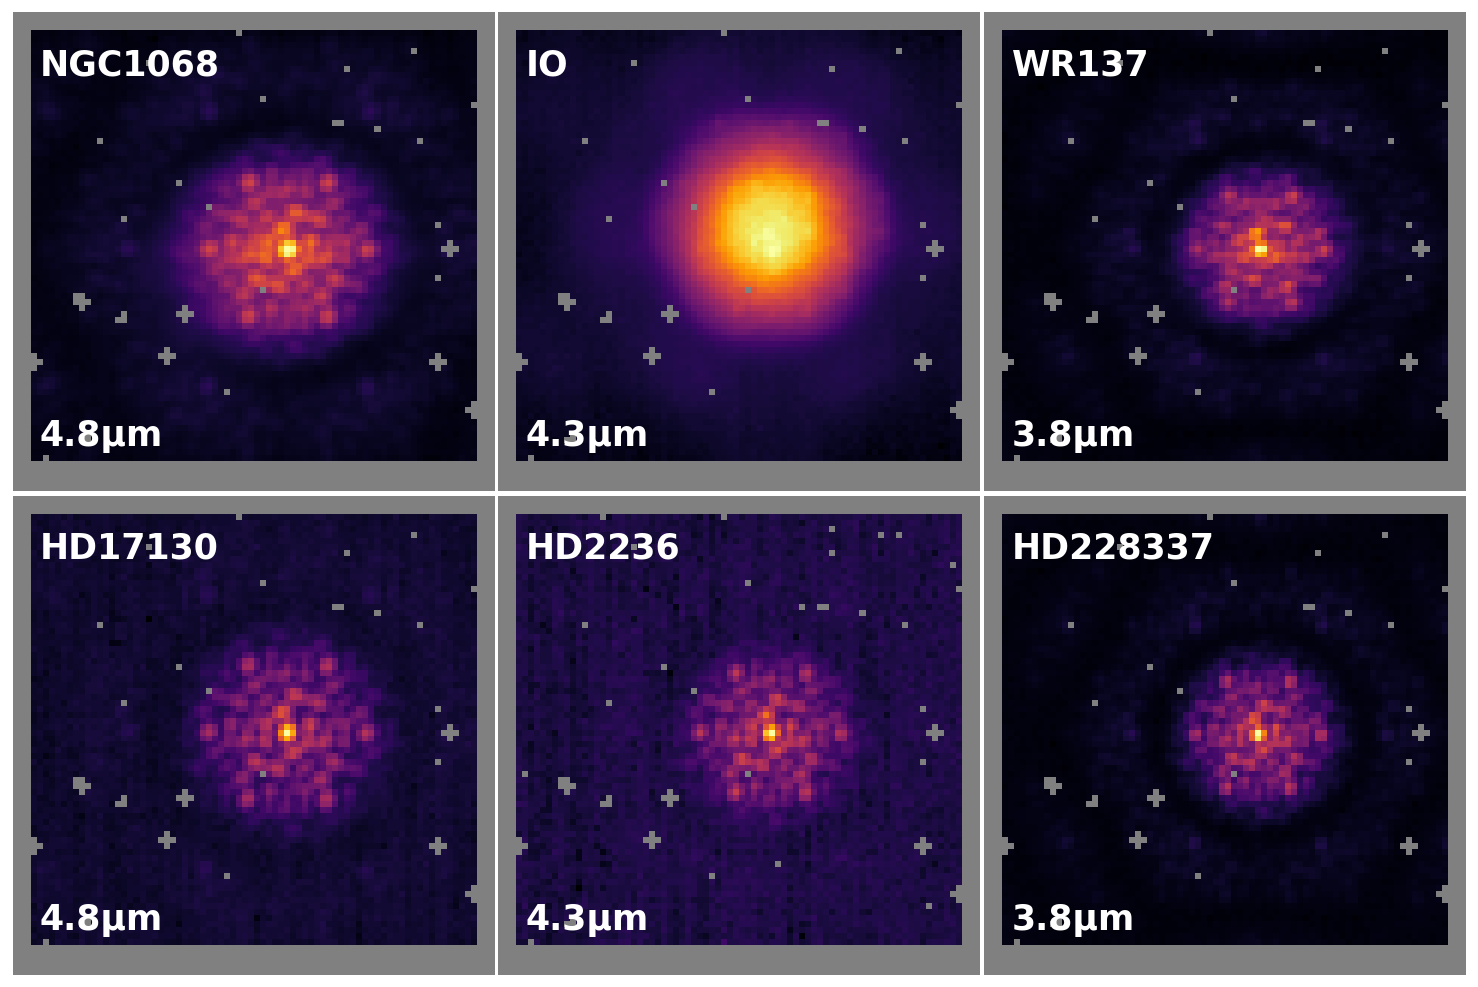

In [6]:
plt.figure(figsize=(15 / 2, 5))

for i, key in enumerate(interferograms.keys()):
    plt.subplot(2, 3, i + 1)
    plt.axis("off")
    plt.imshow(
        interferograms[key],
        cmap=inferno,
        norm=mpl.colors.PowerNorm(0.5),
        aspect="auto",
    )
    font_dict = {"family": "sans-serif", "color": "white", "size": 10, "weight": "bold"}

    match i % 3:
        case 0:
            filt = "4.8μm"
        case 1:
            filt = "4.3μm"
        case 2:
            filt = "3.8μm"
    plt.text(4, 69, key, fontdict=font_dict)
    plt.text(4, 7, filt, fontdict=font_dict)

    # plt.subplot(2, 3, 1)

plt.subplots_adjust(hspace=0.01, wspace=0.01)
# plt.savefig(f"{save_path}/interferograms.pdf", dpi=500, bbox_inches="tight")
plt.show()

# Images

In [7]:
def get_dist(params_path, filt, norm=True, get_fluxes=False):
    params = np.load(params_path, allow_pickle=True).item()
    print(params["log_dist"].keys())
    dist = 10 ** params["log_dist"][filt]
    if norm:
        dist /= dist.sum()
    if get_fluxes:
        print("Flux:", params["fluxes"].keys())
        return dist, params["fluxes"]
    return dist


def get_f(f_list, assertion=True):
    if assertion:
        assert len(f_list) == 20

    fs = list(f_list.values())[:5] + list(f_list.values())[10:15]
    return 10 ** np.array(fs).mean()


best_images = {}

## NGC1068

In [8]:
#### IMPLANE ####
this_path = f"{save_path}/NGC1068/5170358/"
# save_path = "/Users/mc/data/nt_outputs/NGC1068/5169788/"


diff = 13
r, f = get_dist(f"{this_path}/{diff+0}/params.npy", "F480M", get_fluxes=True)
rf = get_f(f)
r *= rf
g, f = get_dist(f"{this_path}/{diff+20}/params.npy", "F430M", get_fluxes=True)
gf = get_f(f)
g *= gf
b, f = get_dist(f"{this_path}/{diff+40}/params.npy", "F380M", get_fluxes=True)
bf = get_f(f)
b *= bf


power = 0.4
clipped = 0.25

piccy = np.stack([r, g, b], axis=-1)
piccy /= piccy.max()
piccy = piccy**power  # adjust brightness
piccy = np.clip(piccy, 0, clipped)  # remove negative values
piccy /= piccy.max()
ngc_image_plane = piccy


#### DISCO ####
this_path = f"{save_path}/ngc1068/5821787/10/"

params = np.load(this_path + "params.npy", allow_pickle=True).item()

r = 10 ** params["log_dist"]["F480M"]
g = 10 ** params["log_dist"]["F430M"]
b = 10 ** params["log_dist"]["F380M"]

r *= rf / r.sum()
g *= gf / g.sum()
b *= bf / b.sum()

# print(r.shape)
piccy = np.stack([r, g, b], axis=-1)
piccy /= piccy.max()
piccy = piccy**power  # adjust brightness
piccy = np.clip(piccy, 0, clipped)  # remove negative values
piccy /= piccy.max()

# # plt.imshow(piccy)
ngc_disco = piccy

print(ngc_disco.shape)
best_images["NGC1068"] = {
    "implane": ngc_image_plane,
    "disco": ngc_disco,
}

dict_keys(['F480M'])
Flux: dict_keys(['01260_001_02_03_1', '01260_001_02_03_2', '01260_001_02_03_3', '01260_001_02_03_4', '01260_001_02_03_5', '01260_002_02_03_1', '01260_002_02_03_2', '01260_002_02_03_3', '01260_002_02_03_4', '01260_002_02_03_5', '01260_103_02_03_1', '01260_103_02_03_2', '01260_103_02_03_3', '01260_103_02_03_4', '01260_103_02_03_5', '01260_104_02_03_1', '01260_104_02_03_2', '01260_104_02_03_3', '01260_104_02_03_4', '01260_104_02_03_5'])
dict_keys(['F430M'])
Flux: dict_keys(['01260_001_04_03_1', '01260_001_04_03_2', '01260_001_04_03_3', '01260_001_04_03_4', '01260_001_04_03_5', '01260_002_04_03_1', '01260_002_04_03_2', '01260_002_04_03_3', '01260_002_04_03_4', '01260_002_04_03_5', '01260_103_04_03_1', '01260_103_04_03_2', '01260_103_04_03_3', '01260_103_04_03_4', '01260_103_04_03_5', '01260_104_04_03_1', '01260_104_04_03_2', '01260_104_04_03_3', '01260_104_04_03_4', '01260_104_04_03_5'])
dict_keys(['F380M'])
Flux: dict_keys(['01260_001_06_03_1', '01260_001_06_03_2', '0

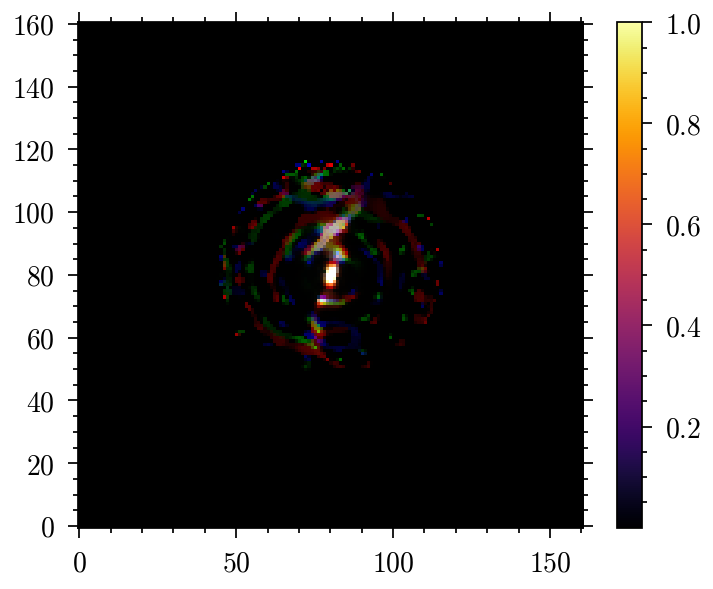

In [9]:
plt.imshow(ngc_disco)
plt.colorbar()

In [10]:
from astropy.io import fits

lbti0 = fits.open(
    f"{save_path}/ngc1068/Re_ NGC1068 Processed Image (1)/ngc1068_paperversion_rldeconv.fits"
)
# lbti0 = fits.open(path + "data/LBTI/ngc1068_paperversion_rldeconv.fits")
lbti0 = np.array(lbti0[0].data)
lbti0 = np.clip(lbti0, 0)
lbti0 /= lbti0.max()

# lbti1 = fits.open(path + "data/LBTI/NGC1068_deconvolved_rl.fits")
lbti1 = fits.open(
    f"{save_path}/ngc1068/Re_ NGC1068 Processed Image (1)/NGC1068_deconvolved_rl.fits"
)
lbti1 = np.array(lbti1[0].data)
lbti1 = np.clip(lbti1, 0)
lbti1 /= lbti1.max()

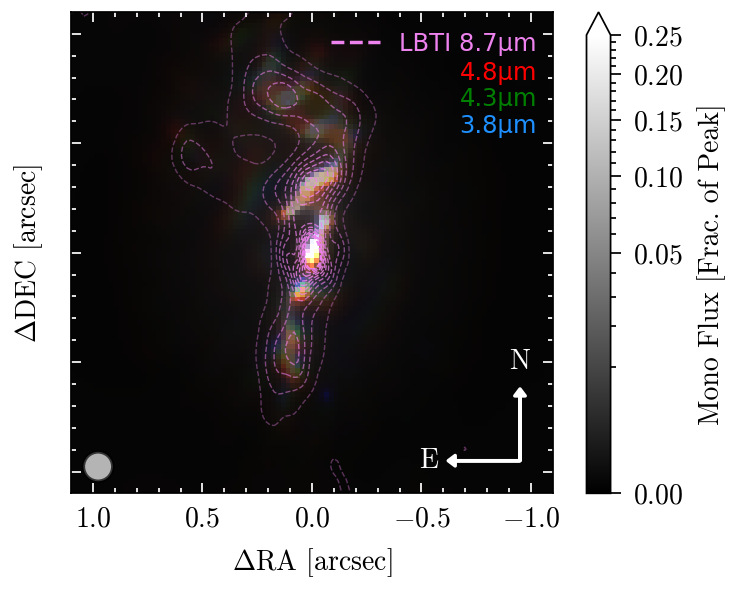

In [11]:
pixel_scale = 0.065524085  # arcsec / pixel
diameter = 6.603464  # meters

fig, ax = plt.subplots(figsize=(3.5, 2.5))

c = dorito.plotting.plot_result(
    ax,
    ngc_image_plane,
    pixel_scale=pixel_scale / 3,  # arcseconds/pixel
    scale=1.6,
    # norm=mpl.colors.LogNorm(),
    diff_lim=0.5 * dlu.rad2arcsec(4.3e-6 / diameter),
    translate=(0.0, 0.07),
    ticks=[-1, -0.5, 0, 0.5, 1],
    # ticks=np.arange(-1, 1.5, 0.5),  # , 0.5, 1.0],
)

smbh = (0.03, -0.1)
# ax.axline(smbh, slope=cone1, color="cyan", linestyle="--", lw=0.5)
# ax.axline(smbh, slope=cone2, color="cyan", linestyle="--", lw=0.5)
# ax.contour(lbti0, , colors="red")
c = plot_contour(
    ax,
    lbti1,
    levels=np.linspace(0, clipped**power, 13) ** (1 / power),
    # cmap="spring",
    cmap=None,
    colors="violet",
    pixel_scale=18e-3,  # arcseconds/pixel
    scale=1.6,
    # alpha=0.8,
    alpha=np.linspace(0, 1.0, 13) ** (power),
    # norm=mpl.colors.PowerNorm(0.5),
    # diff_lim=0.5 * dlu.rad2arcsec(4.3e-6 / diameter),
    linewidths=0.4,
    linestyles="dashed",
    # label="LBTI",
    ticks=[-1, -0.5, 0, 0.5, 1],
    # ticks=np.arange(-1, 1.5, 0.5),  # , 0.5, 1.0],
)
# Manual legend entries:
handles = [
    plt.Line2D([0], [0], color="violet", linestyle="dashed", label="LBTI 8.7μm"),
]


# Arrow parameters
arrow_length = 5 * pixel_scale  # in pixels
origin = -0.95, -0.95  # starting point of arrows (in pixel coords)

# Draw North arrow
ax.annotate(
    "",
    xy=(origin[0], origin[1] + arrow_length),
    xytext=origin,
    arrowprops=dict(
        facecolor="white", edgecolor="white", width=1e-3, headwidth=3, headlength=2
    ),
)
ax.text(
    origin[0],
    origin[1] + arrow_length + 1 * pixel_scale,
    "N",
    color="white",
    ha="center",
    va="bottom",
    fontsize=8,
)

# Draw East arrow
ax.annotate(
    "",
    xy=(origin[0] + arrow_length, origin[1]),
    xytext=origin,
    arrowprops=dict(
        facecolor="white", edgecolor="white", width=1e-3, headwidth=3, headlength=2
    ),
)
ax.text(
    origin[0] + arrow_length + 2 * pixel_scale,
    origin[1],
    "E",
    color="white",
    ha="left",
    va="center",
    fontsize=8,
)

font_dict = {
    "family": "sans-serif",
    # "color": "#FED7BC",
    "size": 7,
    # "weight": "bold",
}
ax.text(-0.675, 0.9 - 0.11, "4.8μm", fontdict=font_dict, color="red")
ax.text(-0.675, 0.78 - 0.11, "4.3μm", fontdict=font_dict, color="green")
ax.text(-0.673, 0.66 - 0.11, "3.8μm", fontdict=font_dict, color="dodgerblue")

ax.legend(
    handles=handles,
    fontsize=8,
    loc=(0.52, 0.89),
    # loc="upper right",
    labelcolor="violet",
    prop=font_dict,
)


ax.tick_params(which="both", color="white", direction="in")
ax.set_yticklabels([])

# Create a fake ScalarMappable
cmap = plt.cm.binary_r
sm = mpl.cm.ScalarMappable(
    norm=mpl.colors.PowerNorm(power, vmin=0, vmax=clipped), cmap=cmap
)
sm.set_array([])

# Add colorbar
cbar = plt.colorbar(sm, ax=ax, extend="max", label="Mono Flux [Frac. of Peak]")
# ax.scatter(*smbh, marker="+", color="cyan", s=20, zorder=10)
# fig.colorbar(c, ax=ax)
# plt.title("Updated Version")
# plt.savefig("files/ngc_lbti.pdf", dpi=500, bbox_inches="tight")
plt.savefig(f"{save_path}ngc_lbti.pdf", dpi=600, bbox_inches="tight")
plt.show()

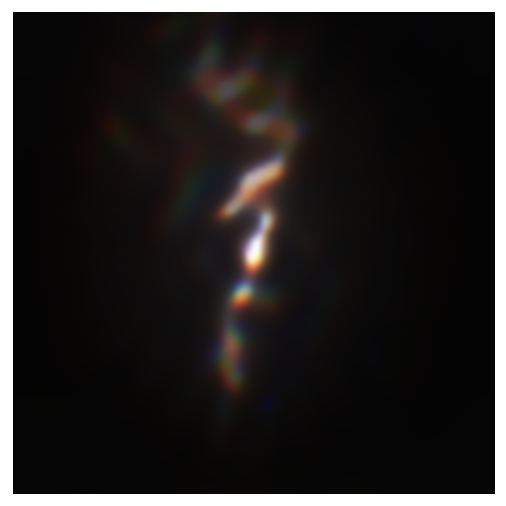

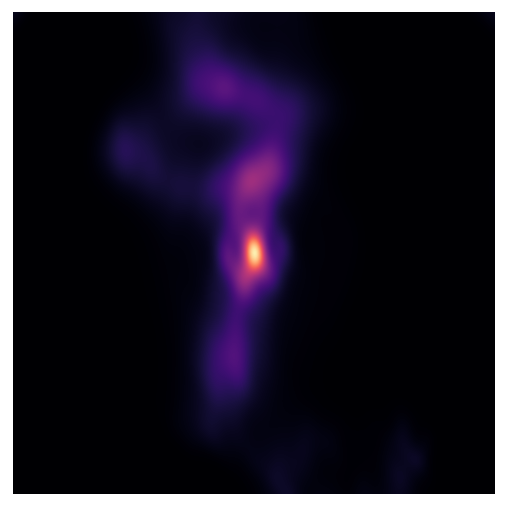

In [12]:
pixel_scale = 0.065524085  # arcsec / pixel
diameter = 6.603464  # meters

fig, ax = plt.subplots(figsize=(3.5, 2.5))

c = plot_result(
    ax,
    ngc_image_plane,
    pixel_scale=pixel_scale / 3,  # arcseconds/pixel
    scale=1.7,
    # norm=mpl.colors.LogNorm(),
    # diff_lim=0.5 * dlu.rad2arcsec(4.3e-6 / diameter),
    translate=(0.0, 0.07),
    ticks=[-1, -0.5, 0, 0.5, 1],
    interpolation="bicubic",
    # ticks=np.arange(-1, 1.5, 0.5),  # , 0.5, 1.0],
)
plt.axis("off")
plt.savefig("/Users/mc/Downloads/JWST_NGC1068.png", dpi=600, bbox_inches="tight")

plt.show()

fig, ax = plt.subplots(figsize=(3.5, 2.5))
c = plot_result(
    ax,
    lbti1,
    # cmap="afmhot_u",
    cmap="magma",
    norm=mpl.colors.PowerNorm(0.35, vmin=0, vmax=1),
    pixel_scale=18e-3,  # arcseconds/pixel
    scale=1.3,
    ticks=[-1, -0.5, 0, 0.5, 1],
    interpolation="bicubic",
)
# fig.colorbar(c, ax=ax)
plt.axis("off")


plt.savefig("/Users/mc/Downloads/LBTI_NGC1068.png", dpi=600, bbox_inches="tight")
plt.show()

## Io

In [13]:
io_implane = get_dist(
    f"{save_path}/io/4984113/15/params.npy", "01373_017_02_04_4_F430M"
)
io_implane = np.pad(io_implane, 15, mode="constant", constant_values=0)

io_disco = np.zeros((161, 161))
best_images["IO"] = {
    "implane": io_implane / io_implane.max(),
    "disco": np.ones((161, 161)),
}

for im in best_images["IO"].values():
    print(im.shape)

dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])
(161, 161)
(161, 161)


## WR137

In [14]:
def get_fr(f_list, assertion=True):
    fs = list(f_list.values())[:4]
    return 10 ** np.array(fs).mean()


def get_fb(f_list, assertion=True):
    fs = list(f_list.values())[4:]
    return 10 ** np.array(fs).mean()


r, f = get_dist(save_path + "/wr137/5805071/3/params.npy", "F480M", get_fluxes=True)
rf = get_fr(f, assertion=False)
r *= rf
b, f = get_dist(save_path + "/wr137/5805071/3/params.npy", "F380M", get_fluxes=True)
bf = get_fb(f, assertion=False)
b *= bf

# r = np.roll(r, 4, axis=0)
b = np.roll(b, -1, axis=0)


g = (r + b) / 2

power = 0.4
# clipped = 0.25

piccy = np.stack([r, g, b], axis=-1)
piccy /= piccy.max()
piccy = piccy**power  # adjust brightness
# piccy = np.clip(piccy, 0, clipped)  # remove negative values
piccy /= piccy.max()
mte_image_piccy = piccy

dict_keys(['F380M', 'F480M'])
Flux: dict_keys(['01349_003_02_03_1', '01349_003_02_03_2', '01349_003_02_03_3', '01349_003_02_03_4', '01349_003_04_03_1', '01349_003_04_03_2', '01349_003_04_03_4', '01349_005_02_03_1', '01349_005_03_03_1'])
dict_keys(['F380M', 'F480M'])
Flux: dict_keys(['01349_003_02_03_1', '01349_003_02_03_2', '01349_003_02_03_3', '01349_003_02_03_4', '01349_003_04_03_1', '01349_003_04_03_2', '01349_003_04_03_4', '01349_005_02_03_1', '01349_005_03_03_1'])


In [15]:
from scipy.ndimage import gaussian_filter

# pixel_scale = model.psf_pixel_scale / model.oversample
pixel_scale = 0.065524085  # arcsec / pixel
diameter = 6.603464  # meters


x = np.load(save_path + "/wr137/quickgo_MTE.npy", allow_pickle=True).item()
r = 10 ** x["log_dist"]["F480M"]
b = 10 ** x["log_dist"]["F380M"]
r *= rf / r.sum()
b *= bf / b.sum()
g = (r + b) / 2


print(r.shape)
piccy = np.stack([r, g, b], axis=-1)
piccy /= piccy.max()
piccy = piccy**power  # adjust brightness
piccy /= piccy.max()

# # plt.imshow(piccy)
mte_disco_piccy = np.pad(
    piccy, ((20, 20), (20, 20), (0, 0)), mode="constant", constant_values=0
)

(121, 121)


In [16]:
mte_disco_piccy.at[0, :, 0].set(0).shape

(161, 161, 3)

In [17]:
# plt.imshow(mte_image_piccy.at[..., 1].set(0))

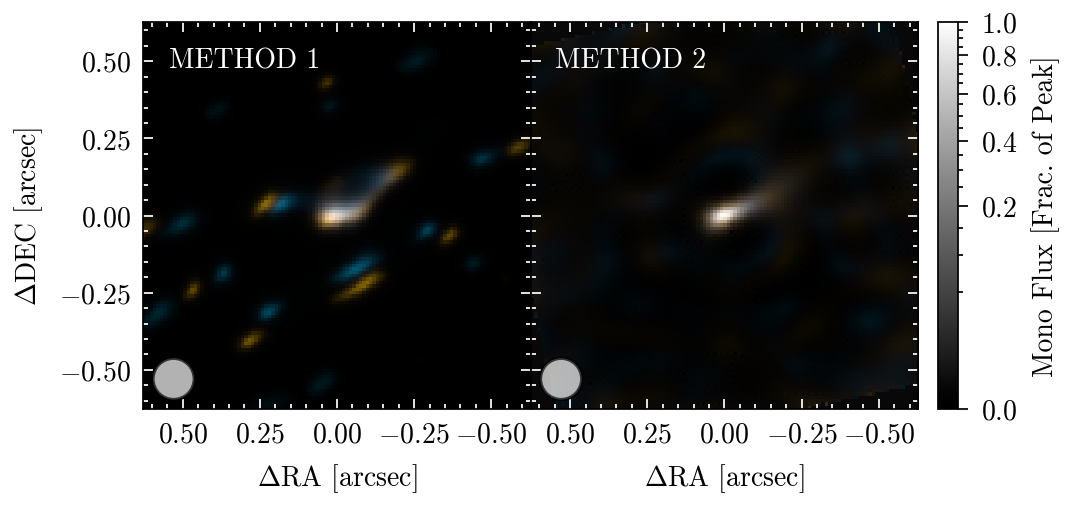

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(4, 2.5), sharey=True)

tix = [-0.5, -0.25, 0, 0.25, 0.5]

c = plot_result(
    ax[0],
    mte_image_piccy,
    pixel_scale=pixel_scale / 6,  # arcseconds/pixel
    scale=1.4,
    diff_lim=0.5 * dlu.rad2arcsec(4.3e-6 / diameter),
    ticks=tix,
)
ax[0].text(
    0.3,
    0.5,
    "METHOD 1",
    color="white",
    fontsize=8,
    ha="center",
    va="center",
    fontweight="bold",
    transform=ax[0].transData,
)
# ax[0].set_yticklabels([])

c = plot_result(
    ax[1],
    mte_disco_piccy,
    pixel_scale=pixel_scale / 6,  # arcseconds/pixel
    scale=1.4,
    diff_lim=0.5 * dlu.rad2arcsec(4.3e-6 / diameter),
    axis_labels={"xlabel": r"$\Delta$RA [arcsec]", "ylabel": ""},
    ticks=tix,
)

ax[1].text(
    -0.95,
    0.5,
    "METHOD 2",
    color="white",
    fontsize=8,
    ha="center",
    va="center",
    fontweight="bold",
    transform=ax[0].transData,
)

for i in [0, 1]:
    ax[i].tick_params(which="both", color="white", direction="in")


bottom = min(ax[0].get_position().y0, ax[1].get_position().y0)
top = max(ax[0].get_position().y1, ax[1].get_position().y1)

a = 0.0275
cax = fig.add_axes(
    [
        ax[1].get_position().x1 + 0.02,  # right of second subplot
        bottom - a,
        0.02,
        top - bottom + 2 * a,
    ]
)

# Add the colorbar to that axis
# Create a fake ScalarMappable
sm = mpl.cm.ScalarMappable(
    norm=mpl.colors.PowerNorm(power, vmin=0, vmax=1), cmap="binary_ur"
)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax, label="Mono Flux [Frac. of Peak]")


fig.subplots_adjust(hspace=0.0, wspace=0.0)

plt.savefig(f"{save_path}/MTE.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [19]:
# from scipy.signal import correlate2d

# arr = correlate2d(r, g, "same")

# plt.imshow(arr, "viridis", norm=mpl.colors.PowerNorm(0.5))
# plt.colorbar()

In [20]:
from scipy.ndimage import gaussian_filter

# pixel_scale = model.psf_pixel_scale / model.oversample
pixel_scale = 0.065524085  # arcsec / pixel
diameter = 6.603464  # meters


# bfgs_model.params["log_dist"]
def blur(factor, arr, wavelength):

    # wavelength in metres
    # wavel = np.dot(*model.filters[filter])
    wavel = wavelength

    # FWHM in pixels
    lambda_over_d = dlu.rad2arcsec(wavel / diameter)  # arcseconds
    lambda_over_d /= pixel_scale  # pixels
    fwhm = factor * lambda_over_d
    sigma = float(fwhm / (2 * (2 * np.log(2)) ** 0.5))

    return gaussian_filter(arr, sigma=(sigma))


x = np.load(save_path + "/wr137/quickgo.npy", allow_pickle=True).item()
r = 10 ** x["log_dist"]["F480M"]
b = 10 ** x["log_dist"]["F380M"]
r *= rf / r.sum()
b *= bf / b.sum()
g = (r + b) / 2

print(r.shape)
piccy = np.stack([r, g, b], axis=-1)
piccy /= piccy.max()
piccy = piccy**power  # adjust brightness
piccy /= piccy.max()

# plt.imshow(piccy)
piccy = np.pad(piccy, ((20, 20), (20, 20), (0, 0)), mode="constant", constant_values=0)
print(piccy.shape)


wr137_implane = np.zeros((161, 161))
wr137_disco = piccy
best_images["WR137"] = {
    "implane": wr137_implane / wr137_implane.max(),
    "disco": wr137_disco / wr137_disco.max(),
}

(121, 121)
(161, 161, 3)


## Panel plot

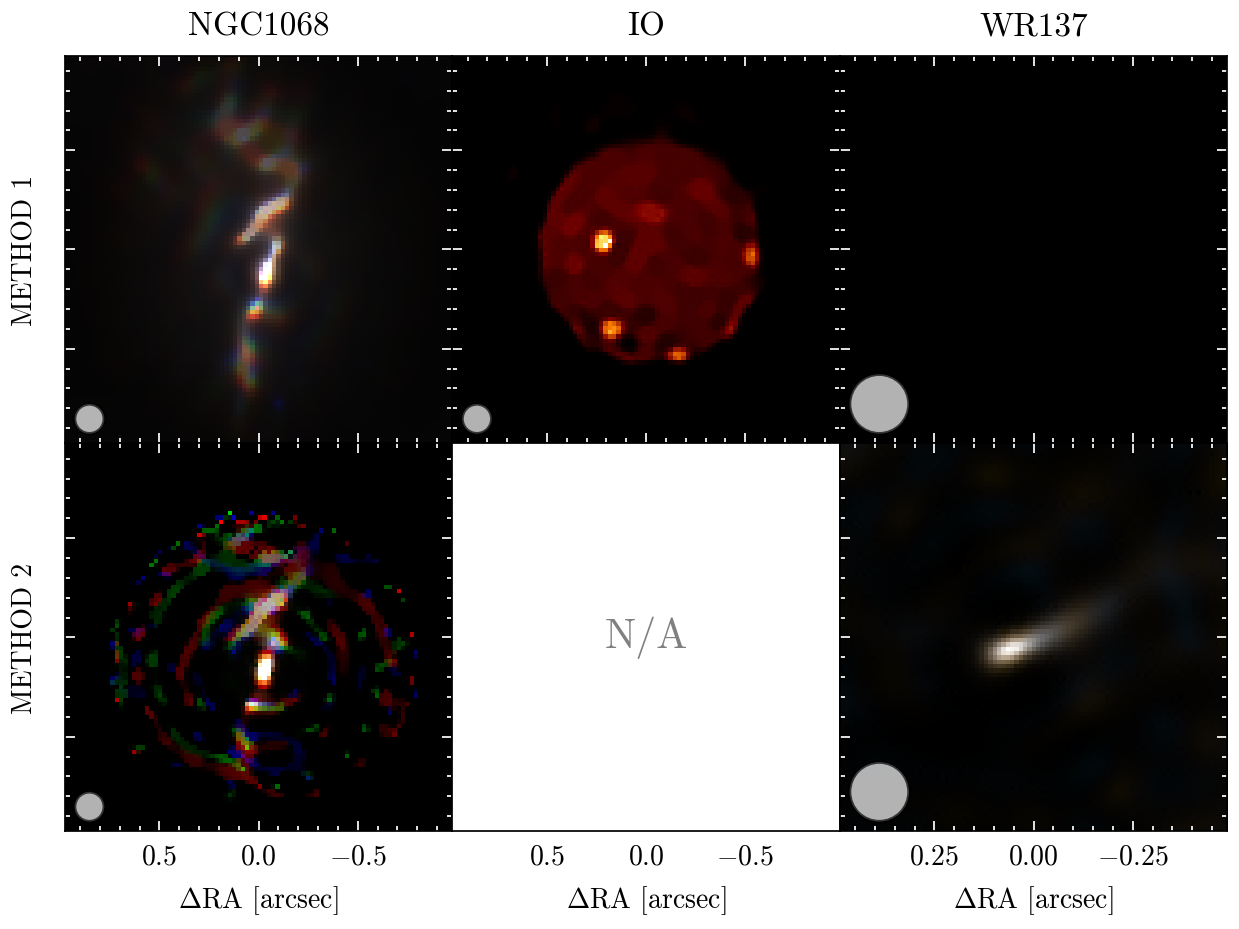

In [21]:
from dLux import utils as dlu

psf_pixel_scale = 0.065524085  # arcsec / pixel
diameter = 6.603464  # meters

fig, axes = plt.subplots(2, 3, figsize=(6, 4.03))  # , sharex=True, sharey=True)

for i, key in enumerate(list(best_images.keys())):

    for image, row in zip(
        [best_images[key]["implane"], best_images[key]["disco"]], [0, 1]
    ):
        osamp = 3 if i != 2 else 6
        ticks = [-0.5, 0, 0.5] if i != 2 else [-0.25, 0, 0.25]
        if i == 1 and row == 1:
            cmap = "binary_ur"
            vmax = 1
            difflim = None
            axes[row, i].text(
                0,
                0,
                "N/A",
                color="gray",
                fontsize=12,
                ha="center",
                va="center",
                transform=axes[row, i].transData,
                fontweight="bold",
            )
        else:
            cmap = "afmhot_u"
            vmax = None
            difflim = dlu.rad2arcsec(4.8e-6 / (2 * diameter))
        com = compute_com_physical(image, psf_pixel_scale / osamp)

        im = plot_result(
            axes[row, i],
            image,
            psf_pixel_scale / osamp,
            cmap=cmap,
            scale=1.8,
            norm=mpl.colors.PowerNorm(0.8, vmin=0, vmax=vmax),
            # norm=mpl.colors.LogNorm(vmin=2e-4),
            diff_lim=difflim,
            aspect="auto",
            axis_labels={"xlabel": "", "ylabel": ""},
            ticks=ticks,
            translate=-com,
        )
    if i == 0:
        axes[0, i].set(ylabel="METHOD 1")
        axes[1, i].set(ylabel="METHOD 2")

    # if i != 0:
    #     for j in [0, 1]:
    #         axes[j, i].tick_params(which="both", left=False)

    # if i != 2:
    #     for j in [0, 1]:
    #         axes[j, i].tick_params(which="both", right=False)

    # axes[0, i].tick_params(which="both", bottom=False)
    # axes[1, i].tick_params(which="both", top=False)
    axes[0, i].tick_params(which="both", color="white", direction="in")
    axes[1, i].tick_params(which="both", color="white", direction="in")

    axes[0, i].set(title=key, yticklabels=["", "", ""])
    axes[1, i].set(xlabel=r"$\Delta$RA [arcsec]", yticklabels=["", "", ""])
    # font_dict = {"family": "sans-serif", "color": "white", "size": 10, "weight": "bold"}

    # if i

fig.subplots_adjust(hspace=0.0, wspace=0.0)
# plt.savefig(f"{save_path}/.pdf", dpi=500, bbox_inches="tight")
plt.show()

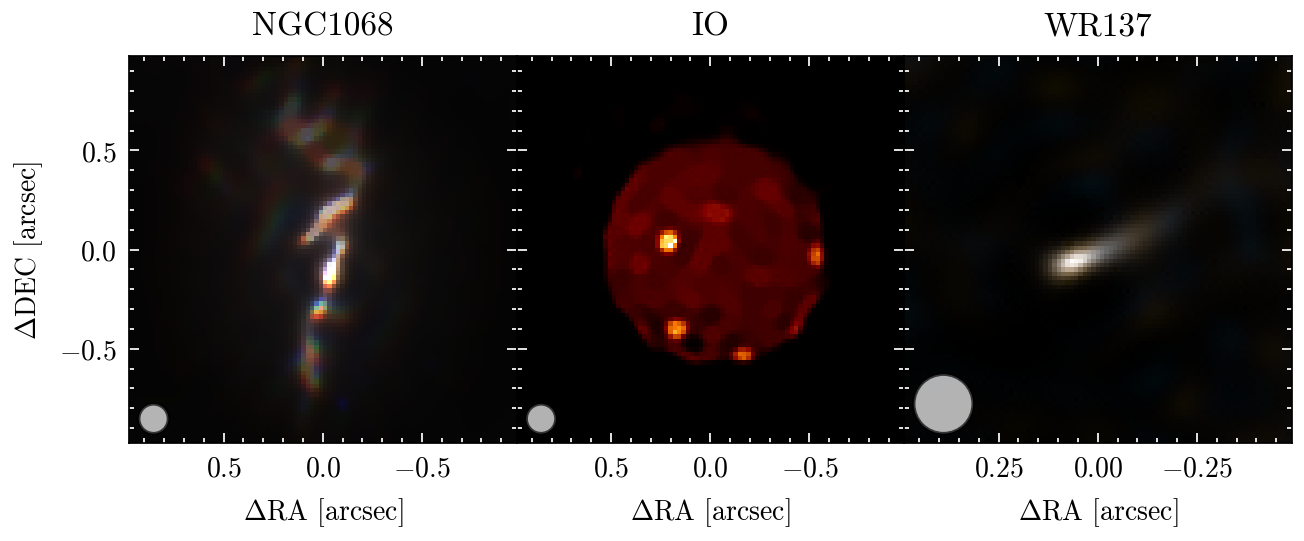

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(6, 4.03))  # , sharex=True, sharey=True)

images = [
    best_images["NGC1068"]["implane"],
    best_images["IO"]["implane"],
    best_images["WR137"]["disco"],
]

for i, key in enumerate(list(best_images.keys())):

    osamp = 3 if i != 2 else 6
    ticks = [-0.5, 0, 0.5] if i != 2 else [-0.25, 0, 0.25]
    image = images[i]
    com = compute_com_physical(image, psf_pixel_scale / osamp)
    im = plot_result(
        axes[i],
        image,
        psf_pixel_scale / osamp,
        cmap=cmap,
        scale=1.8,
        norm=mpl.colors.PowerNorm(0.8, vmin=0, vmax=vmax),
        # norm=mpl.colors.LogNorm(vmin=2e-4),
        diff_lim=difflim,
        # aspect="auto",
        # axis_labels={"xlabel": "", "ylabel": ""},
        ticks=ticks,
        translate=-com,
    )

    # if i != 0:
    #     for j in [0, 1]:
    #         axes[j, i].tick_params(which="both", left=False)

    # if i != 2:
    #     for j in [0, 1]:
    #         axes[j, i].tick_params(which="both", right=False)

    # axes[0, i].tick_params(which="both", bottom=False)
    # axes[1, i].tick_params(which="both", top=False)
    axes[i].tick_params(which="both", color="white", direction="in")
    axes[i].tick_params(which="both", color="white", direction="in")

    axes[i].set(title=key, xlabel=r"$\Delta$RA [arcsec]")
    if i != 0:
        axes[i].set(yticklabels=["", "", ""], ylabel="")
    # font_dict = {"family": "sans-serif", "color": "white", "size": 10, "weight": "bold"}

    # if i

fig.subplots_adjust(hspace=0.0, wspace=0.0)
# plt.savefig(f"files/3PANEL.pdf", dpi=600, bbox_inches="tight")
plt.show()

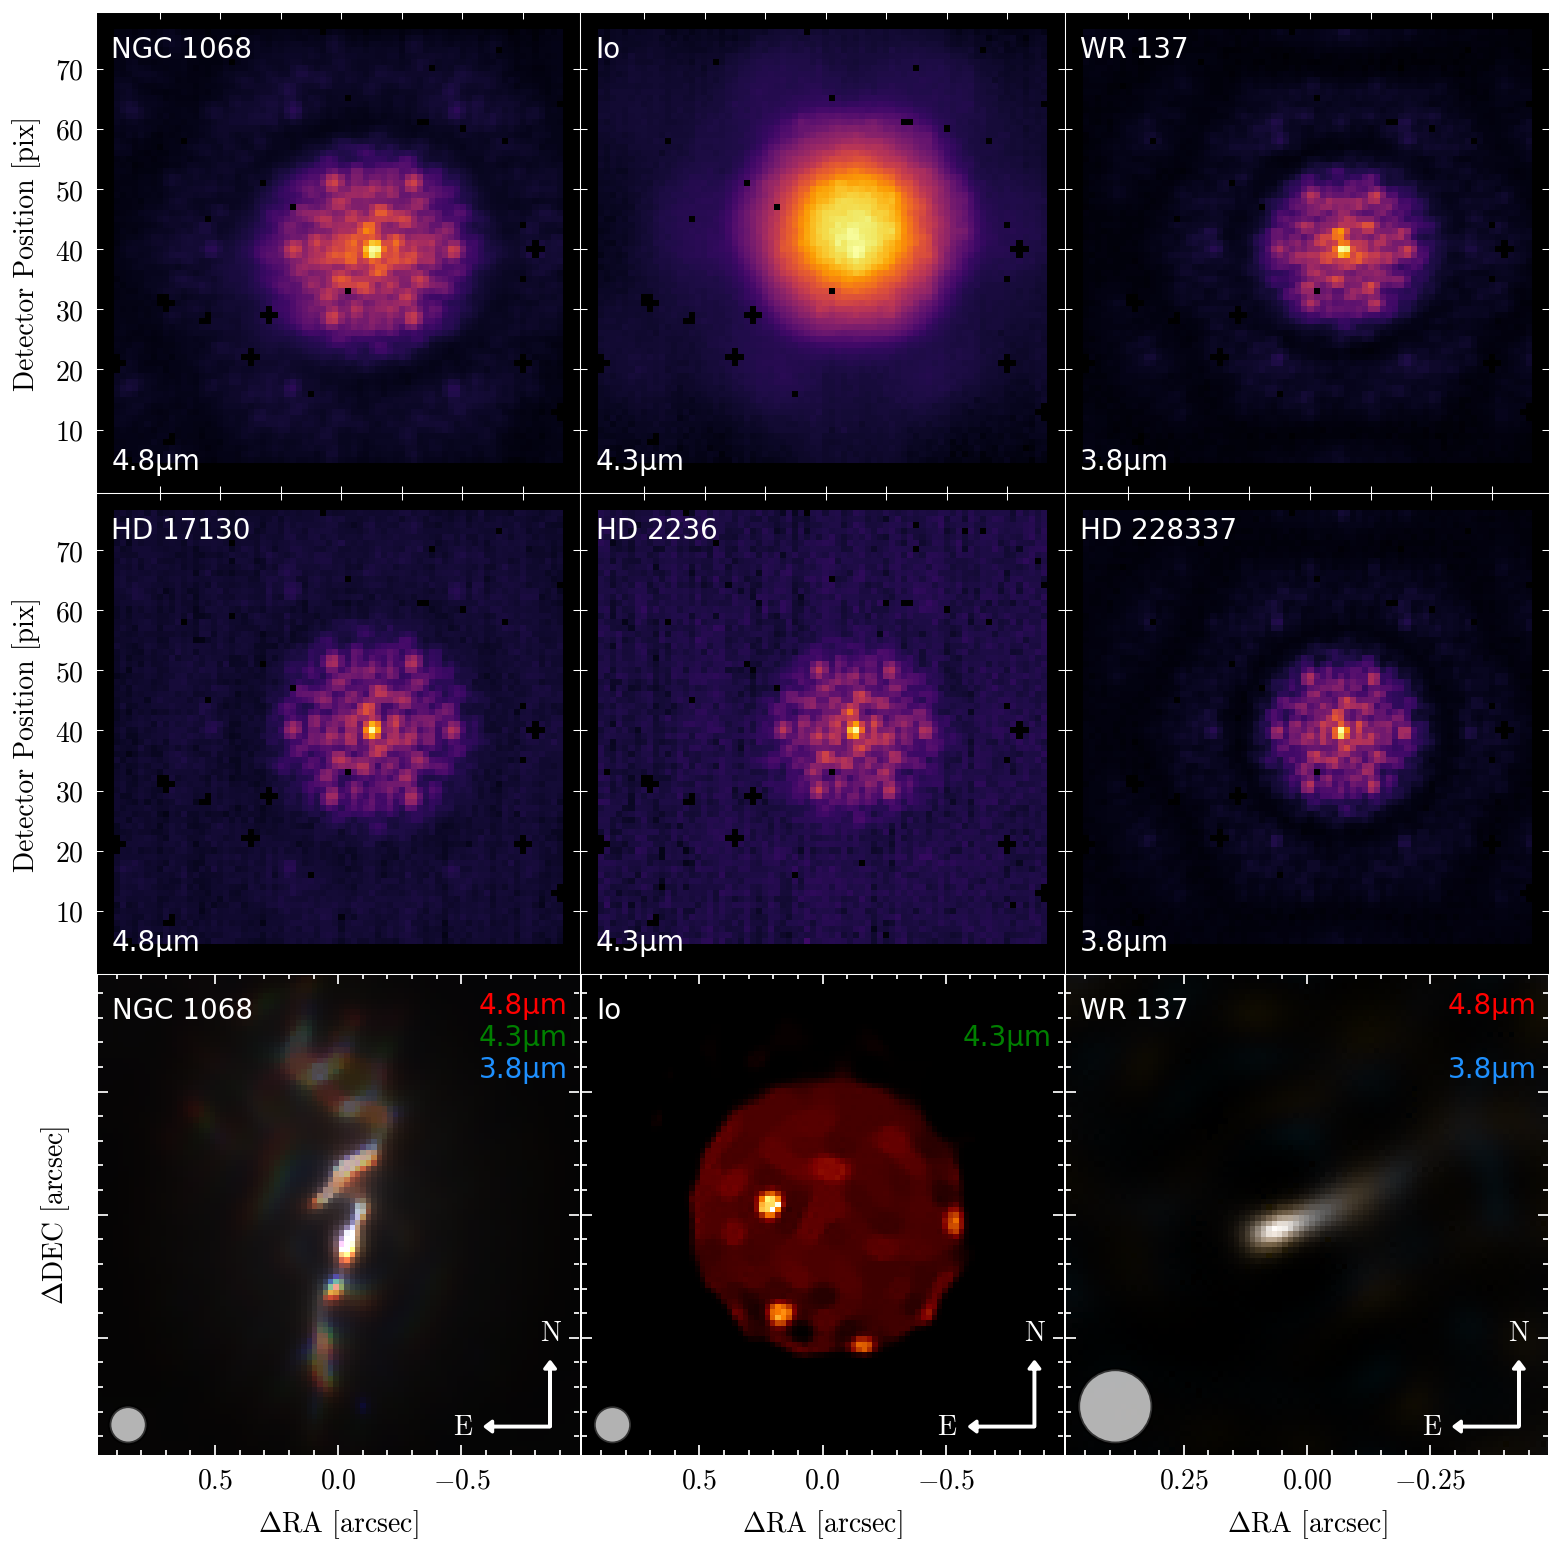

In [23]:
inferno.set_bad("k", 1.0)
title_dict = {
    "NGC1068": r"NGC 1068",
    "IO": "Io",
    "WR137": "WR 137",
    "HD17130": "HD 17130",
    "HD2236": "HD 2236",
    "HD228337": "HD 228337",
}


fig, axes = plt.subplots(3, 3, figsize=(7.5, 7.5))

for i, key in enumerate(interferograms.keys()):
    ax = axes.flat[i]
    # ax.axis("off")
    im = ax.imshow(
        interferograms[key],
        cmap=inferno,
        norm=mpl.colors.PowerNorm(0.5),
        aspect="auto",
    )

    for spine in ax.spines.values():
        spine.set_edgecolor("white")
        spine.set_linewidth(0.3)

    font_dict = {
        "family": "sans-serif",
        "color": "white",
        "size": 8,
        # "weight": "bold",
    }

    match i % 3:
        case 0:
            filt = "4.8μm"
        case 1:
            filt = "4.3μm"
        case 2:
            filt = "3.8μm"
    # Show the key in data coordinates (relative to the image)
    ax.text(2, 72, title_dict[key], fontdict=font_dict, transform=ax.transData)
    ax.text(2, 3.5, filt, fontdict=font_dict, transform=ax.transData)
    ax.minorticks_off()

    if i > 2:
        ax.tick_params(bottom=False)

    ax.tick_params(
        which="major",
        color="white",
        direction="in",
        grid_color="white",
        width=0.3,
        length=2,
    )
    ax.set(
        xticks=range(10, 80, 10),
        yticks=range(10, 80, 10),
        ylabel="Detector Position [pix]",
    )

    if i % 3 != 0:
        ax.set(yticklabels=[], ylabel="")
    # plt.subplot(2, 3, 1)

for i, key in enumerate(list(best_images.keys())):

    ax = axes.flat[6 + i]

    for spine in ax.spines.values():
        spine.set_edgecolor("white")
        spine.set_linewidth(0.3)

    for side in ["bottom", "left", "right"]:
        ax.spines[side].set_visible(False)

    osamp = 3 if i != 2 else 6
    ticks = [-0.5, 0, 0.5] if i != 2 else [-0.25, 0, 0.25]
    image = images[i]
    com = compute_com_physical(image, psf_pixel_scale / osamp)
    im = plot_result(
        ax,
        image,
        psf_pixel_scale / osamp,
        cmap=cmap,
        scale=1.8,
        norm=mpl.colors.PowerNorm(0.8, vmin=0, vmax=vmax),
        # norm=mpl.colors.LogNorm(vmin=2e-4),
        diff_lim=difflim,
        # aspect="auto",
        # axis_labels={"xlabel": "", "ylabel": ""},
        ticks=ticks,
        translate=-com,
    )

    ax.tick_params(which="both", color="white", direction="in")

    target = list(interferograms.keys())[i]
    pts = np.array([0.92, 0.8])
    pts = pts if target != "WR137" else pts / 2
    ax.text(*pts, title_dict[target], fontdict=font_dict, transform=ax.transData)

    ax.set(
        # title=key,
        xlabel=r"$\Delta$RA [arcsec]",
        yticklabels=["", "", ""],
    )
    if i != 0:
        ax.set(yticklabels=["", "", ""], ylabel="")

    pts = np.array([-0.57, 0.82])
    pts = pts if target != "WR137" else pts / 2
    diff = 0.13 if target != "WR137" else 0.065

    # F480M
    if target != "IO":
        ax.text(
            *pts,
            "4.8μm",
            fontdict={"family": "sans-serif", "size": 8},
            color="red",
            transform=ax.transData,
        )

    # F430M
    if target == "IO" or target == "NGC1068":
        ax.text(
            pts[0],
            pts[1] - diff,
            "4.3μm",
            fontdict={"family": "sans-serif", "size": 8},
            color="green",
            transform=ax.transData,
        )

    # F380M
    if target != "IO":
        ax.text(
            pts[0],
            pts[1] - 2 * diff,
            "3.8μm",
            fontdict={"family": "sans-serif", "size": 8},
            color="dodgerblue",
            transform=ax.transData,
        )

    # Arrow parameters
    arrow_length = (
        4 * pixel_scale if target != "WR137" else 2 * pixel_scale
    )  # in pixels
    origin = (
        (-0.86, -0.86) if target != "WR137" else (-0.86 / 2, -0.86 / 2)
    )  # starting point of arrows (in pixel coords)
    distance = 1 if target != "WR137" else 0.5
    # Draw North arrow
    ax.annotate(
        "",
        xy=(origin[0], origin[1] + arrow_length),
        xytext=origin,
        arrowprops=dict(
            facecolor="white", edgecolor="white", width=1e-3, headwidth=3, headlength=2
        ),
    )
    ax.text(
        origin[0],
        origin[1] + arrow_length + distance * pixel_scale,
        "N",
        color="white",
        ha="center",
        va="bottom",
        fontsize=8,
    )

    # Draw East arrow
    ax.annotate(
        "",
        xy=(origin[0] + arrow_length, origin[1]),
        xytext=origin,
        arrowprops=dict(
            facecolor="white", edgecolor="white", width=1e-3, headwidth=3, headlength=2
        ),
    )
    ax.text(
        origin[0] + arrow_length + 2 * distance * pixel_scale,
        origin[1],
        "E",
        color="white",
        ha="left",
        va="center",
        fontsize=8,
    )


plt.subplots_adjust(hspace=0.0, wspace=0.0)
# plt.tight_layout(pad=0.0)
plt.savefig(f"{save_path}/9PANEL.pdf", dpi=500, bbox_inches="tight")
plt.show()

# L-curves

In [24]:
Lpath = save_path + "/io/4984113/"
# path = "/Users/mc/data/nt_outputs/IO/4984113/"

# dists = [
#     get_dist(path + run + "/params.npy", "01373_017_02_04_1_F430M")
#     for run in sorted(os.listdir(path), key=lambda x: int(x))
# ]

dists = [
    [
        get_dist(Lpath + run + "/params.npy", f"01373_017_02_04_{_}_F430M")
        for run in sorted(os.listdir(Lpath), key=lambda x: int(x))
    ]
    for _ in range(1, 6)
]

runs = sorted(os.listdir(Lpath), key=lambda x: int(x))
balances = [
    np.load(Lpath + run + "/balance.npy", allow_pickle=True).item() for run in runs
]

priors = np.array([b["priors"] for b in balances]).T
likelihoods = np.array([b["likelihoods"] for b in balances]).T
coeffs = np.array([b["args"]["reg_dict"]["TV"][0] for b in balances])

dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])
dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])
dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])
dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])
dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])
dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])
dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M',

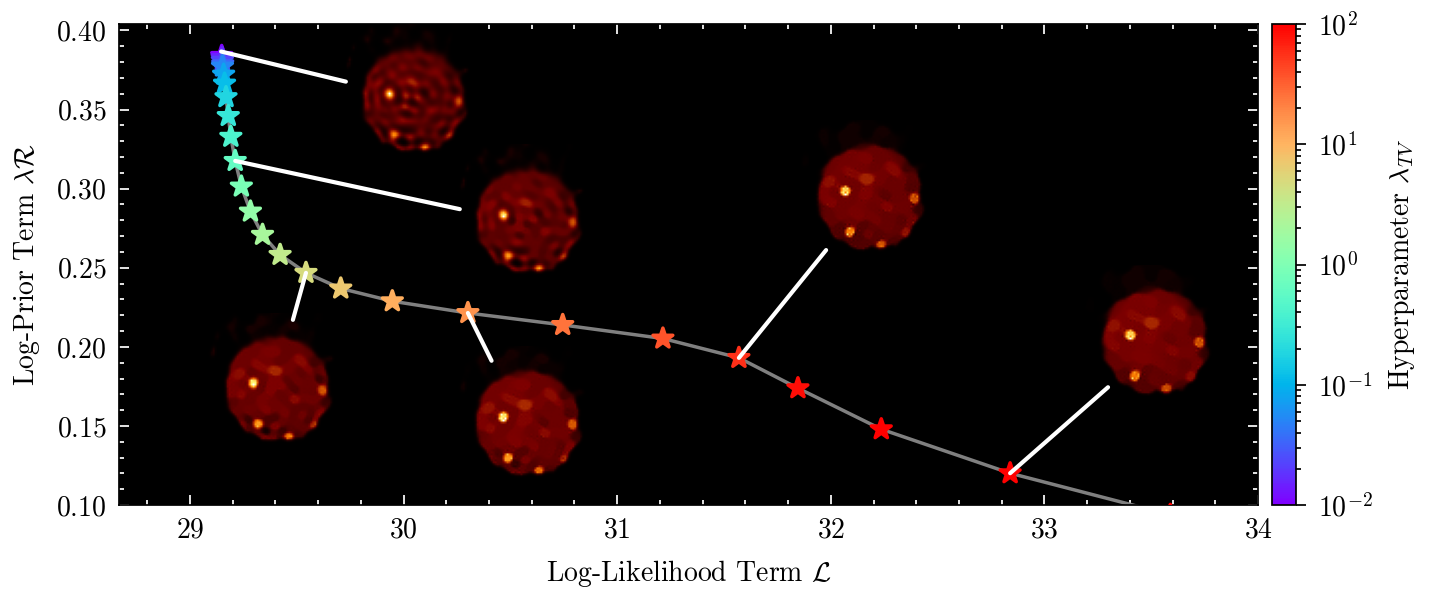

In [25]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionPatch
import numpy as onp
import jax.numpy as np

# --- (assume likelihoods, priors, coeffs, runs, dists, compute_com_physical,
#      psf_pixel_scale, osamp, plot_result are already defined in your session) ---

# ensure numeric arrays for safe float conversion
likelihoods = np.asarray(likelihoods)
priors = np.asarray(priors)
coeffs = np.asarray(coeffs)

fig, ax = plt.subplots(figsize=(7, 2.5))  # <-- fixed: was "fix" in your code

ax.set_facecolor("k")
sc = ax.scatter(
    likelihoods[0],
    priors[0],
    c=coeffs,
    norm=mpl.colors.LogNorm(vmax=1e2),
    cmap="rainbow",
    marker="*",
    zorder=10,
)

for d in range(0, 1):
    ax.plot(likelihoods[d], priors[d], c="gray")

ax.set(
    xlim=(None, 34),
    ylim=(0.1, None),
    xlabel=r"Log-Likelihood Term $\mathcal{L}$",
    ylabel=r"Log-Prior Term $\lambda\mathcal{R}$",
)

# for i, coeff in enumerate(coeffs):
# ax.annotate(
#     rf"$10^{np.log10(coeff):.0f}$, {runs[i]}",
#     (likelihoods[i], priors[i]),
#     fontsize=6,
#     color="black",
#     ha="center",
#     va="center",
# )

fig.colorbar(
    sc, ax=ax, label=r"Hyperparameter $\lambda_{TV}$", pad=0.01
)  # use the scatter mappable

corners = [
    (0.1, 0.7),
    (0.2, 0.45),
    (-0.02, 0.1),
    (0.2, 0.03),
    (0.5, 0.5),
    (0.75, 0.2),
]

runs_idx = [0, 11, 16, 19, 22, 25]
radius = 30  # pixels for circular mask
ax.tick_params(which="both", color="white", direction="in")

for i, corner in enumerate(corners):
    run = runs_idx[i]
    dist = dists[0][run]

    # create inset axis inside the main axes (coords are in axes fraction)
    axin = ax.inset_axes([corner[0], corner[1], 0.3, 0.3])
    axin.set_aspect("equal")
    axin.axis("off")

    # Try to make a numpy copy for masking/indices (works whether `dist` is numpy or jax)
    try:
        clip_d = onp.clip(np.array(dist), 0, 0.05)
        clip_d[onp.array(dist) < 0.02] = 0
    except Exception:
        # fallback (if dist is a jax array and .at is required in your pipeline)
        clip_d = onp.clip(dist, 0, 0.05).at[dist < 0.02].set(0)
        clip_d = onp.array(clip_d)

    # circular mask
    yy, xx = onp.indices(clip_d.shape)
    center = onp.array(clip_d.shape) / 2
    mask = (xx - center[1]) ** 2 + (yy - center[0]) ** 2 > radius**2
    clip_d[mask] = 0

    # compute COM and plot
    # com = compute_com_physical(clip_d, psf_pixel_scale / 3)
    _im = plot_result(
        axin,
        dist,
        psf_pixel_scale / osamp,
        cmap="afmhot_u",
        scale=1.8,
        norm=mpl.colors.PowerNorm(0.65, vmin=0),
        # translate=-com,
    )

    # connector: use axesA/axesB with coords strings for clarity
    x0 = float(likelihoods[0][run])
    y0 = float(priors[0][run])

    xyBs = [
        (0.1, 0.6),
        (0.1, 0.55),
        (0.68, 0.95),
        (0.32, 0.9),
        (0.27, 0.1),
        (0.25, 0.15),
    ]  # center of the inset

    con = ConnectionPatch(
        xyA=(x0, y0),
        coordsA="data",  # point in main axes (data coords)
        xyB=xyBs[i],
        coordsB="axes fraction",  # center of the inset
        axesA=ax,
        axesB=axin,
        arrowstyle="-",
        color="white",
        linewidth=1.2,
        zorder=1,
        # transform=ax.transFig,
    )
    fig.add_artist(con)

# plt.tight_layout()
plt.savefig(f"{save_path}/io/Lcurve.pdf", dpi=500, bbox_inches="tight")
plt.show()

In [26]:
Lpath = f"{save_path}/NGC1068/5170358/"
# path = "/Users/mc/data/nt_outputs/IO/4984113/"

# dists = [
#     get_dist(path + run + "/params.npy", "01373_017_02_04_1_F430M")
#     for run in sorted(os.listdir(path), key=lambda x: int(x))
# ]

runs = sorted(os.listdir(Lpath), key=lambda x: int(x))[:20]


dists = [
    [get_dist(Lpath + run + "/params.npy", f"F480M") for run in runs]
    for _ in range(1, 6)
]

balances = [
    np.load(Lpath + run + "/balance.npy", allow_pickle=True).item() for run in runs
]

priors = np.array([b["priors"] for b in balances]).T
likelihoods = np.array([b["likelihoods"] for b in balances]).T
coeffs = np.array([b["args"]["reg_dict"]["TV"][0] for b in balances])

dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F480M'])
dict_keys(['F

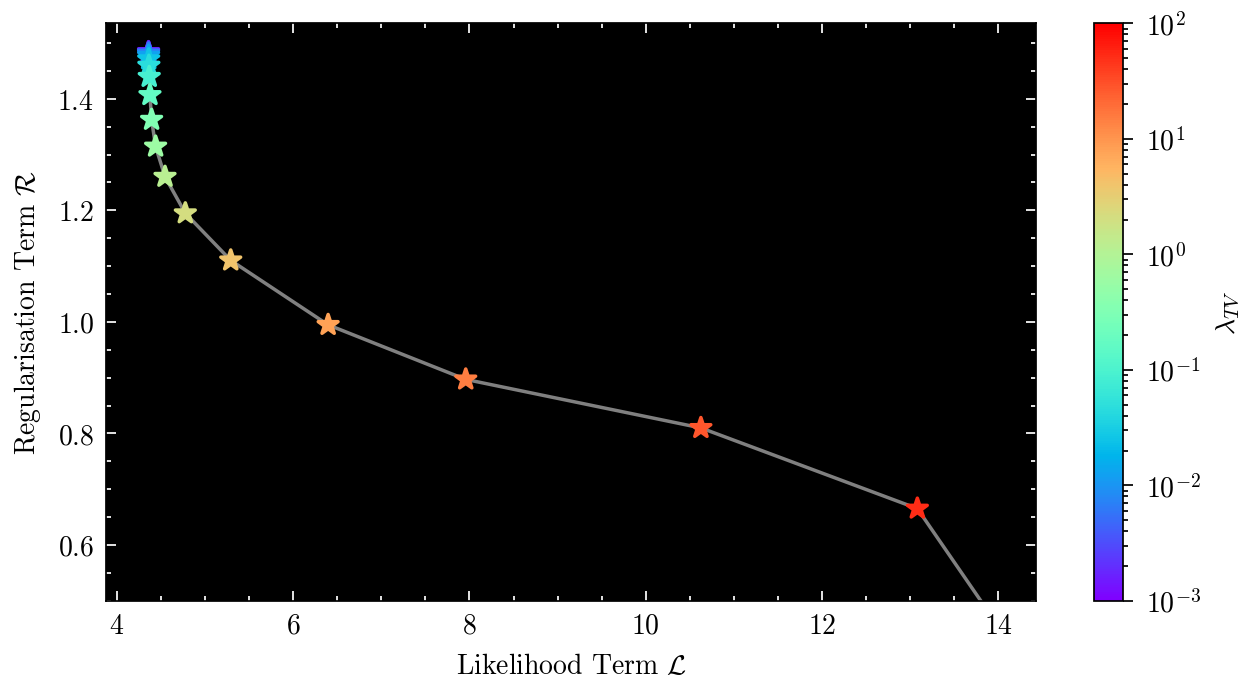

In [27]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionPatch
import numpy as onp
import jax.numpy as np

# --- (assume likelihoods, priors, coeffs, runs, dists, compute_com_physical,
#      psf_pixel_scale, osamp, plot_result are already defined in your session) ---

# ensure numeric arrays for safe float conversion
likelihoods = np.asarray(likelihoods)
priors = np.asarray(priors)
coeffs = np.asarray(coeffs)

fig, ax = plt.subplots(figsize=(6, 3))  # <-- fixed: was "fix" in your code

ax.set_facecolor("k")
sc = ax.scatter(
    likelihoods[0],
    priors[0],
    c=coeffs,
    norm=mpl.colors.LogNorm(vmax=1e2),
    cmap="rainbow",
    marker="*",
    zorder=10,
)

for d in range(0, 1):
    ax.plot(likelihoods[d], priors[d], c="gray")

ax.set(
    # xlim=(None, 34),
    ylim=(0.5, None),
    xlabel=r"Likelihood Term $\mathcal{L}$",
    ylabel=r"Regularisation Term $\mathcal{R}$",
    # yscale="log",
)

# for i, coeff in enumerate(coeffs):
# ax.annotate(
#     rf"$10^{np.log10(coeff):.0f}$, {runs[i]}",
#     (likelihoods[i], priors[i]),
#     fontsize=6,
#     color="black",
#     ha="center",
#     va="center",
# )

fig.colorbar(sc, ax=ax, label=r"$\lambda_{TV}$")  # use the scatter mappable

corners = [
    (0.1, 0.7),
    (0.2, 0.45),
    (-0.02, 0.1),
    (0.2, 0.03),
    # (0.5, 0.5),
    # (0.75, 0.2),
]

runs_idx = [0, 6, 13, 19]
radius = 30  # pixels for circular mask
ax.tick_params(which="both", color="white", direction="in")

for i, corner in enumerate(corners):
    run = runs_idx[i]
    dist = dists[0][run]

    # create inset axis inside the main axes (coords are in axes fraction)
    axin = ax.inset_axes([corner[0], corner[1], 0.3, 0.3])
    axin.set_aspect("equal")
    axin.axis("off")

    # Try to make a numpy copy for masking/indices (works whether `dist` is numpy or jax)
    try:
        clip_d = onp.clip(np.array(dist), 0, 0.05)
        clip_d[onp.array(dist) < 0.02] = 0
    except Exception:
        # fallback (if dist is a jax array and .at is required in your pipeline)
        clip_d = onp.clip(dist, 0, 0.05).at[dist < 0.02].set(0)
        clip_d = onp.array(clip_d)

    # circular mask
    yy, xx = onp.indices(clip_d.shape)
    center = onp.array(clip_d.shape) / 2
    mask = (xx - center[1]) ** 2 + (yy - center[0]) ** 2 > radius**2
    clip_d[mask] = 0

    # # compute COM and plot
    # # com = compute_com_physical(clip_d, psf_pixel_scale / 3)
    # _im = plot_result(
    #     axin,
    #     dist,
    #     psf_pixel_scale / osamp,
    #     cmap="afmhot_u",
    #     scale=1.8,
    #     norm=mpl.colors.PowerNorm(0.8, vmin=0),
    #     # translate=-com,
    # )

    # # connector: use axesA/axesB with coords strings for clarity
    # x0 = float(likelihoods[0][run])
    # y0 = float(priors[0][run])

    # xyBs = [
    #     (0.1, 0.65),
    #     # (0, 0),
    #     (0.1, 0.6),
    #     (0.6, 0.95),
    #     (0.35, 0.95),
    #     (0.3, 0.1),
    #     (0.25, 0.15),
    # ]  # center of the inset

    # con = ConnectionPatch(
    #     xyA=(x0, y0),
    #     coordsA="data",  # point in main axes (data coords)
    #     xyB=xyBs[i],
    #     coordsB="axes fraction",  # center of the inset
    #     axesA=ax,
    #     axesB=axin,
    #     arrowstyle="-",
    #     color="white",
    #     linewidth=1.2,
    #     zorder=1,
    #     # transform=ax.transFig,
    # )
    # fig.add_artist(con)

# plt.tight_layout()
# plt.savefig(f"{save_path}/io/Lcurve.pdf", dpi=500, bbox_inches="tight")
plt.show()

# Io GIF

In [28]:
# path = "/Users/mc/data/nt_outputs/IO/4378318/8/"
Gpath = save_path + "/io/4984113/14/"

params = np.load(Gpath + "/params.npy", allow_pickle=True).item()
print(params["log_dist"].keys())

dists = [
    get_dist(Gpath + "/params.npy", key, norm=False)
    for key in params["log_dist"].keys()
]

dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])
dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])
dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])
dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])
dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])
dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])


dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])


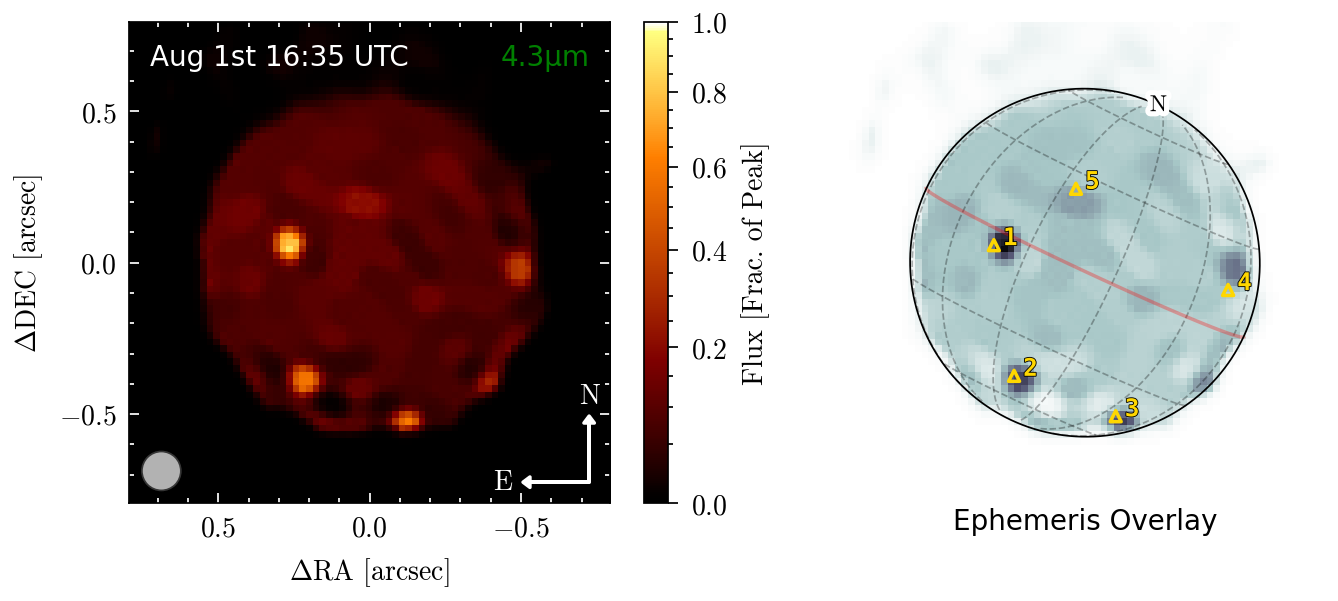

dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])


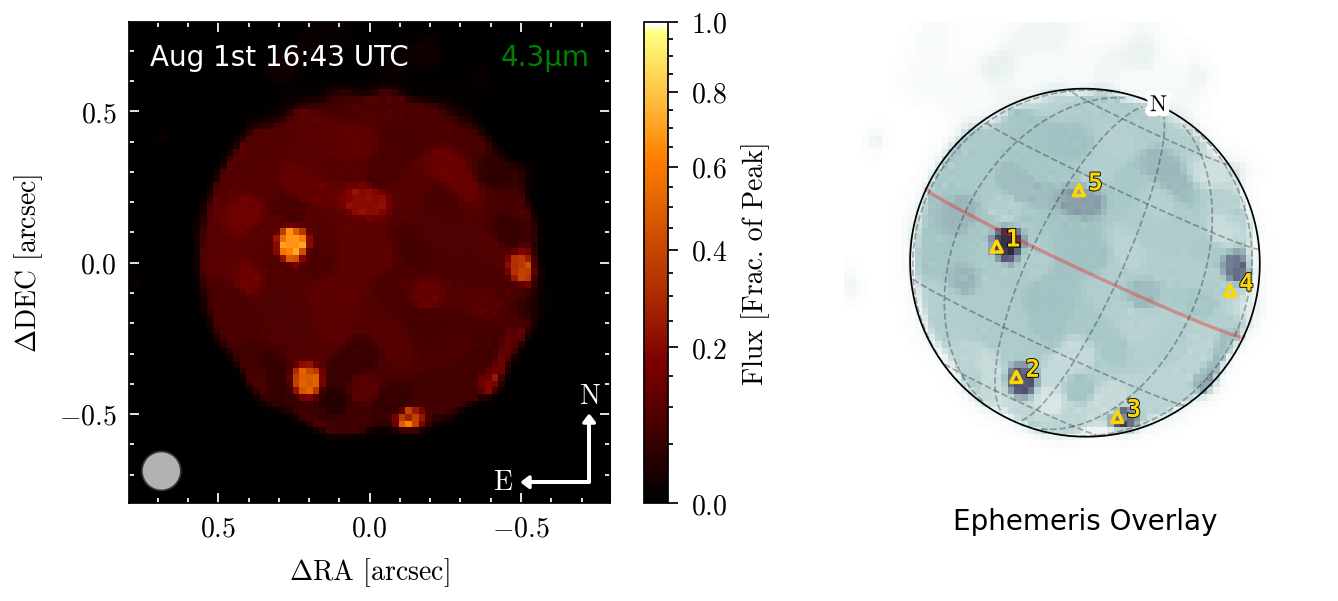

dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])


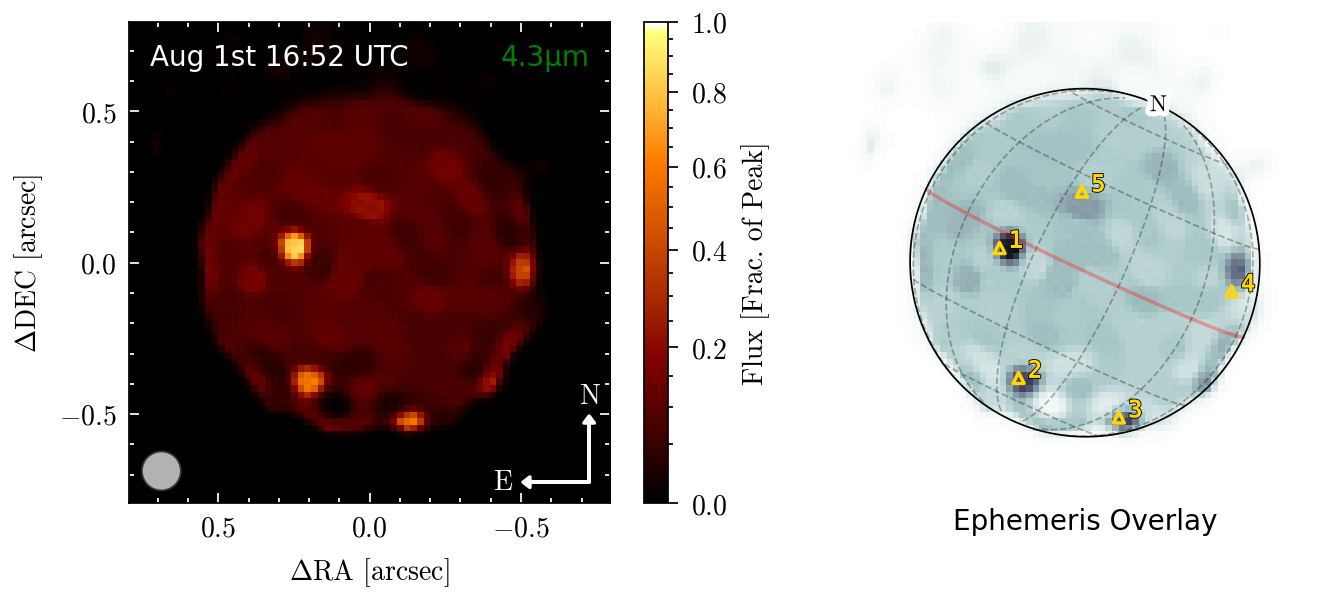

dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])


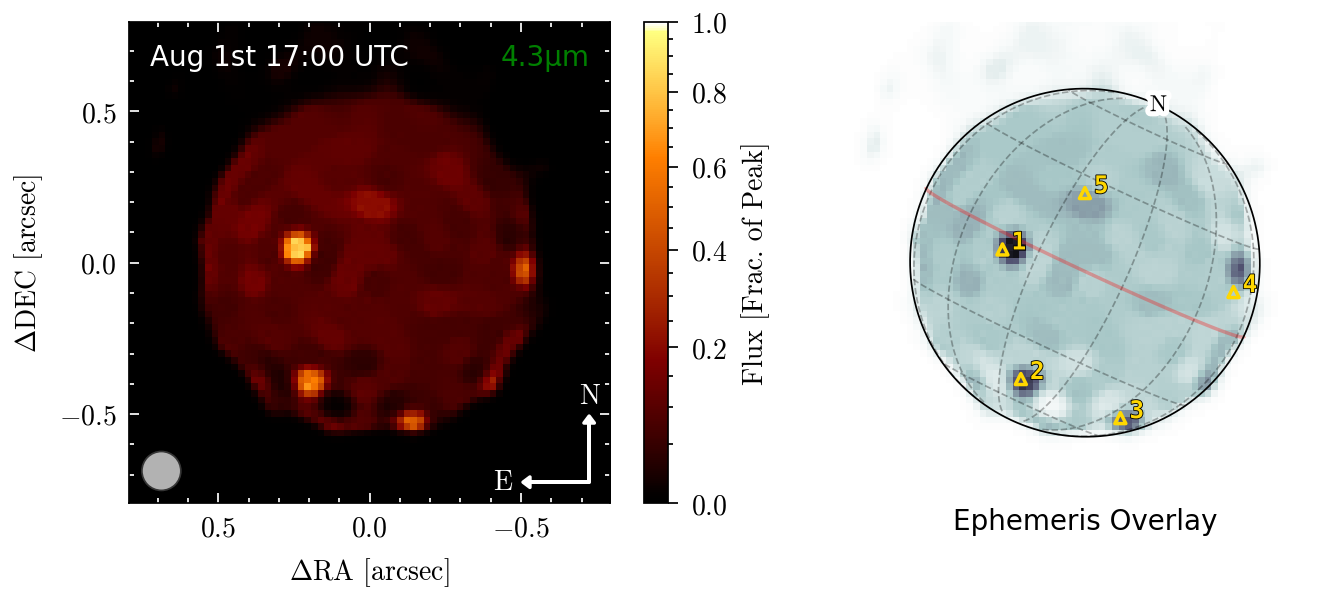

dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])


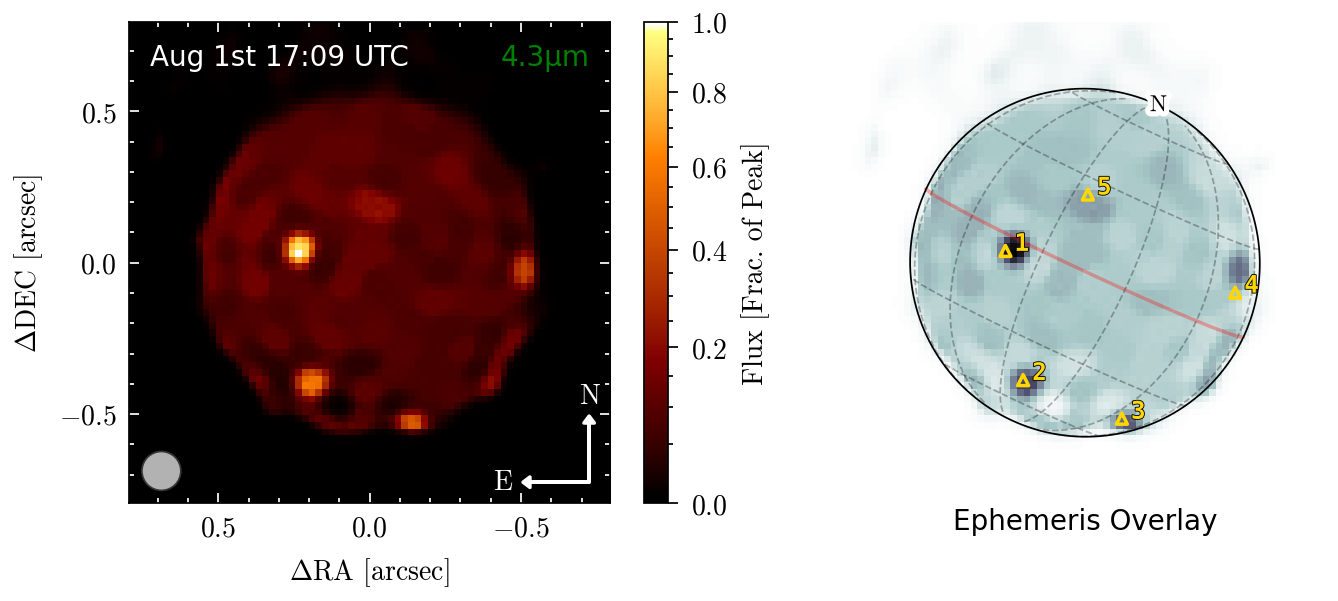

In [29]:
# from planetmapper.kernel_downloader import download_urls

# download_urls("https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/")
# download_urls("https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/")
# download_urls(
#     "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/satellites/jup365.bsp"
# )
# download_urls("https://naif.jpl.nasa.gov/pub/naif/JWST/kernels/spk/")
from astropy.io import fits


def crop(arr, n):
    """Crop a 2D array to a square of size n x n centered in the original array."""
    y, x = arr.shape
    startx = x // 2 - (n // 2)
    starty = y // 2 - (n // 2)
    return arr[starty : starty + n, startx : startx + n]


io_uncal_path = path + "data/JWST/IO/uncal/"
io_peak_flux = np.array(dists).max()
clip_value = 0.1
# clip_value = 0.05
# pixel_scale = 0.065524085 * 3
pixel_scale = 0.065524085 / 3
optics_diameter = 6.603464  # JWST aperture diameter in meters


save_dir = "gifs/spinning_io/"
for exp in io_sci_fits:

    dist = get_dist(Gpath + "params.npy", "_".join([exp.key, exp.filter]), norm=False)
    dist = dist / io_peak_flux

    # clip_d = np.clip(crop(dist, 80), min=0, max=clip_value)
    clip_d = np.clip(dist, min=clip_value, max=clip_value).at[dist < 0.02].set(0)
    # clip_d = dist
    center = compute_com_physical(
        clip_d,
        pixel_scale,
    )  # + np.array([0.045, 0.005])

    # plt.imshow(clip_d)
    # plt.scatter(*center, c="cyan", s=10, marker="x")
    # plt.colorbar()
    # plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(7, 2.5), sharey=True)
    c0 = dorito.plotting.plot_result(
        ax[0],
        dist,
        # clip_d,
        pixel_scale=pixel_scale,
        cmap="afmhot_u",
        # cmap="inferno",
        norm=mpl.colors.PowerNorm(0.7, vmin=0, vmax=1.0),
        translate=-center,
        # translate=-params["positions"][exp.get_key("positions")],
        scale=1.8,
        diff_lim=0.5 * dlu.rad2arcsec(4.3e-6 / optics_diameter),
    )

    c1 = plot_io_with_ephemeris(
        ax[1],
        dist,
        pixel_scale=pixel_scale,
        cmap="bone_ur",
        exp=exp,
        data_dir=io_uncal_path,
        norm=mpl.colors.PowerNorm(0.7, vmin=0, vmax=1.0),
        points=list(features.values()),
        bg_color="white",
        translate=-center,  # / (dist.shape[0] / 75.0),
        # scale=2,
        scale=1.8,
        axis_labels={
            "xlabel": r"$\Delta$RA [arcsec]",
            "ylabel": "",
        },
    )
    ax[1].axis("off")
    # Labelling volcanoes
    coords = []
    for artist in ax[1].collections:
        if hasattr(artist, "get_offsets"):
            coord = artist.get_offsets()[0]
            coords.append(coord)

    eps = 3e-2
    for i, (x, y) in enumerate(coords):  # i should now correctly track the index
        txt = ax[1].text(
            x - eps,
            y,
            f"{i+1}",
            fontsize=7,
            c="gold",
            fontfamily="monospace",
            fontweight="bold",
        )  # Use i in the label

        txt.set_path_effects(
            [
                mpl.patheffects.Stroke(linewidth=0.5, foreground="black"),
                mpl.patheffects.Normal(),
            ]
        )

    fig.colorbar(c0, ax=ax[0], label="Flux [Frac. of Peak]")

    file = fits.open(io_uncal_path + exp.filename + "_uncal.fits")

    time = astropy.time.Time(file[0].header["EXPMID"], format="mjd")
    # ax[0].set_title(f"Aug 1st {time.ymdhms[3]:02}:{time.ymdhms[4]:02} UTC")
    # ax[1].set_title(f"Ephemeris Overlay")

    ax[0].tick_params(which="both", color="white", direction="in")
    ax[1].tick_params(which="both", color="black", direction="in")

    ax[0].text(
        0.725,
        0.725,
        f"Aug 1st {time.ymdhms[3]:02}:{time.ymdhms[4]:02} UTC",
        ha="left",
        va="top",
        fontdict={
            "family": "sans-serif",
            "color": "white",
            "size": 8,
            # "weight": "bold",
        },
        transform=ax[0].transData,
    )

    ax[0].text(
        -0.725,
        0.725,
        "4.3μm",
        ha="right",
        va="top",
        fontdict={
            "family": "sans-serif",
            "color": "green",
            # "color": "#FED7BC",
            "size": 8,
            # "weight": "bold",
        },
        transform=ax[0].transData,
    )

    ax[1].text(
        0.0,
        -0.9,
        f"Ephemeris Overlay",
        ha="center",
        va="bottom",
        fontdict={
            "family": "sans-serif",
            "color": "black",
            "size": 8,
            # "weight": "bold",
        },
        transform=ax[1].transData,
    )

    # Arrow parameters
    arrow_length = 10 * pixel_scale  # in pixels
    origin = 2 * [-0.725]  # starting point of arrows (in pixel coords)
    # Draw North arrow
    ax[0].annotate(
        "",
        xy=(origin[0], origin[1] + arrow_length),
        xytext=origin,
        arrowprops=dict(
            facecolor="white", edgecolor="white", width=1e-3, headwidth=3, headlength=2
        ),
        transform=ax[0].transData,
    )
    ax[0].text(
        origin[0],
        origin[1] + arrow_length + pixel_scale,
        "N",
        color="white",
        ha="center",
        va="bottom",
        fontsize=8,
        transform=ax[0].transData,
    )

    # Draw East arrow
    ax[0].annotate(
        "",
        xy=(origin[0] + arrow_length, origin[1]),
        xytext=origin,
        arrowprops=dict(
            facecolor="white", edgecolor="white", width=1e-3, headwidth=3, headlength=2
        ),
        transform=ax[0].transData,
    )
    ax[0].text(
        origin[0] + arrow_length + 4.5 * pixel_scale,
        origin[1],
        "E",
        color="white",
        ha="left",
        va="center",
        fontsize=8,
        transform=ax[0].transData,
    )

    # plt.tight_layout()
    # fig.colorbar(c1, ax=ax[1])
    plt.subplots_adjust(wspace=0.0)

    # plt.close()
    plt.savefig(f"{save_path}/io_gif/{time.isot}.png", dpi=600)
    plt.show()

# create_gif_from_dir(save_path + "/io_gif/", "io.gif", duration=500)

In [31]:
# create_gif_from_dir(save_path + "/io_gif/", "io.gif", duration=500)

dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])


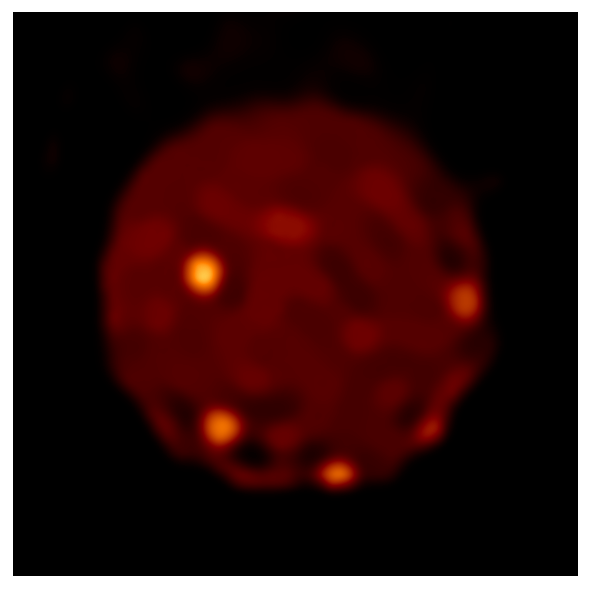

dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])


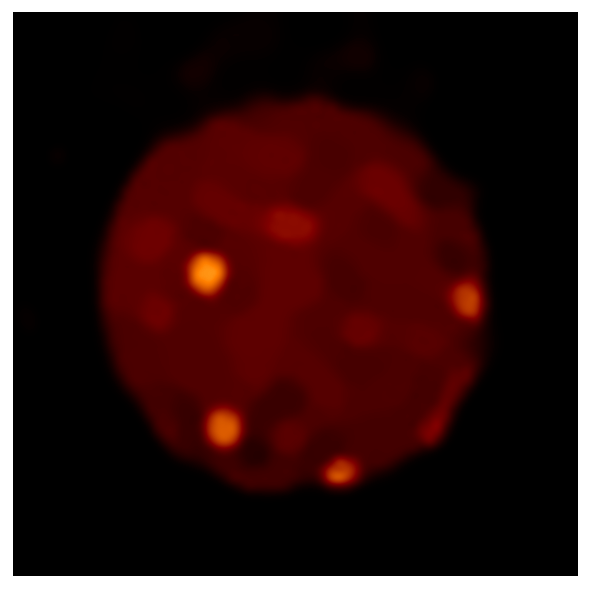

dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])


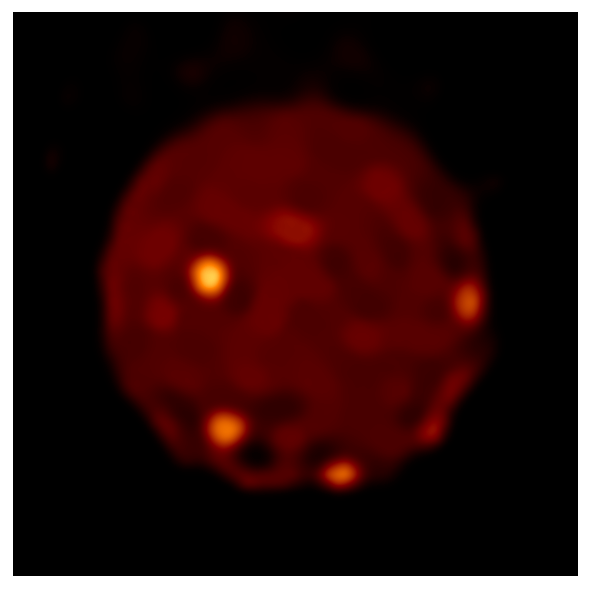

dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])


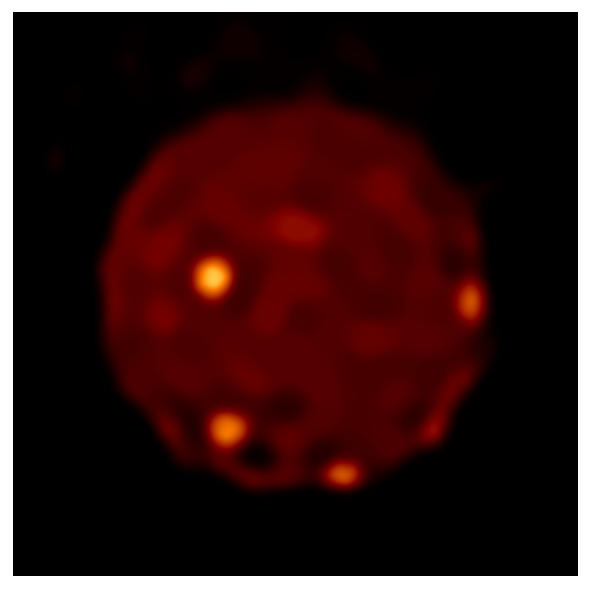

dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])


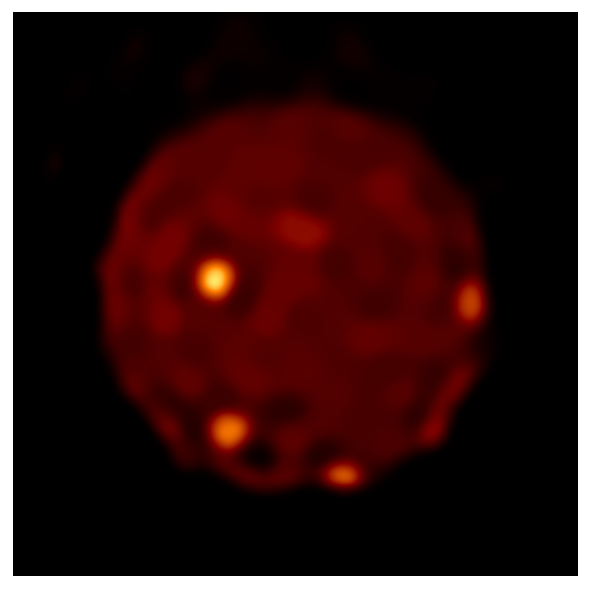

In [32]:
# from planetmapper.kernel_downloader import download_urls

# download_urls("https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/")
# download_urls("https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/")
# download_urls(
#     "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/satellites/jup365.bsp"
# )
# download_urls("https://naif.jpl.nasa.gov/pub/naif/JWST/kernels/spk/")
from astropy.io import fits


def crop(arr, n):
    """Crop a 2D array to a square of size n x n centered in the original array."""
    y, x = arr.shape
    startx = x // 2 - (n // 2)
    starty = y // 2 - (n // 2)
    return arr[starty : starty + n, startx : startx + n]


io_uncal_path = path + "data/JWST/IO/uncal/"
io_peak_flux = np.array(dists).max()
clip_value = 0.1
# clip_value = 0.05
# pixel_scale = 0.065524085 * 3
pixel_scale = 0.065524085 / 3
optics_diameter = 6.603464  # JWST aperture diameter in meters


save_dir = "gifs/spinning_io/"
for idx, exp in enumerate(io_sci_fits):

    dist = get_dist(Gpath + "params.npy", "_".join([exp.key, exp.filter]), norm=False)
    dist = dist / io_peak_flux

    # clip_d = np.clip(crop(dist, 80), min=0, max=clip_value)
    clip_d = np.clip(dist, min=clip_value, max=clip_value).at[dist < 0.02].set(0)
    # clip_d = dist
    center = compute_com_physical(
        clip_d,
        pixel_scale,
    )  # + np.array([0.045, 0.005])

    # plt.imshow(clip_d)
    # plt.scatter(*center, c="cyan", s=10, marker="x")
    # plt.colorbar()
    # plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
    c0 = plot_result(
        ax,
        dist,
        # clip_d,
        pixel_scale=pixel_scale,
        cmap="afmhot_u",
        # cmap="inferno",
        norm=mpl.colors.PowerNorm(0.7, vmin=0, vmax=1.0),
        translate=-center,
        # translate=-params["positions"][exp.get_key("positions")],
        scale=dist.shape[0] / 75.0,
        interpolation="bicubic",
        # diff_lim=0.5 * dlu.rad2arcsec(4.3e-6 / optics_diameter),
    )

    font_dict = {
        "family": "sans-serif",
        "color": "#FED7BC",
        "size": 8,
        "weight": "bold",
    }
    # ax.text(-0.41, 0.67, "4.3μm", fontdict=font_dict)

    # fig.colorbar(c0)

    file = fits.open(io_uncal_path + exp.filename + "_uncal.fits")

    time = astropy.time.Time(file[0].header["EXPMID"], format="mjd")
    # ax.set_title(f"Aug 1st {time.ymdhms[3]:02}:{time.ymdhms[4]:02} UTC")

    plt.axis("off")

    plt.tight_layout()
    plt.savefig(f"files/io_pressgif/{time.isot}.png", dpi=300)
    # plt.close()
    plt.show()

    np.save(f"files/io_pressgif/frame_{idx}.npy", dist)
create_gif_from_dir("files/io_pressgif/", "io.gif", duration=500, loop=0)

In [33]:
def get_exposing(files, eps=1e0, samples=1e4):

    starts = []
    ends = []
    for file in files:

        # print(file[0].header)
        start = astropy.time.Time(file[0].header["EXPSTART"], format="mjd")
        end = astropy.time.Time(file[0].header["EXPEND"], format="mjd")

        starts.append(mins_past_the_hour(start.mjd))
        ends.append(mins_past_the_hour(end.mjd))

    starts = np.array(starts)
    ends = np.array(ends)
    rang = np.linspace(starts.min() - eps, ends.max() + eps, int(samples))

    exposings = np.array(
        [
            np.where(rang > start, 1.0, 0.0) * np.where(rang < end, 1.0, 0.0)
            for start, end in zip(starts, ends)
        ]
    )

    return rang, exposings


def mins_past_the_hour(mjd):
    # Reference time: 5:00 PM (17:00) on August 1st, 2022 UTC
    ref_time = astropy.time.Time("2022-08-01 16:00:00", format="iso", scale="utc")

    # Convert input MJD to an astropy Time object
    current_time = astropy.time.Time(mjd, format="mjd", scale="utc")

    # Compute time difference in minutes
    delta_minutes = (current_time - ref_time).to("min").value

    return delta_minutes

dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])
dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])
dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])
dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])
dict_keys(['01373_017_02_04_1_F430M', '01373_017_02_04_2_F430M', '01373_017_02_04_3_F430M', '01373_017_02_04_4_F430M', '01373_017_02_04_5_F430M'])


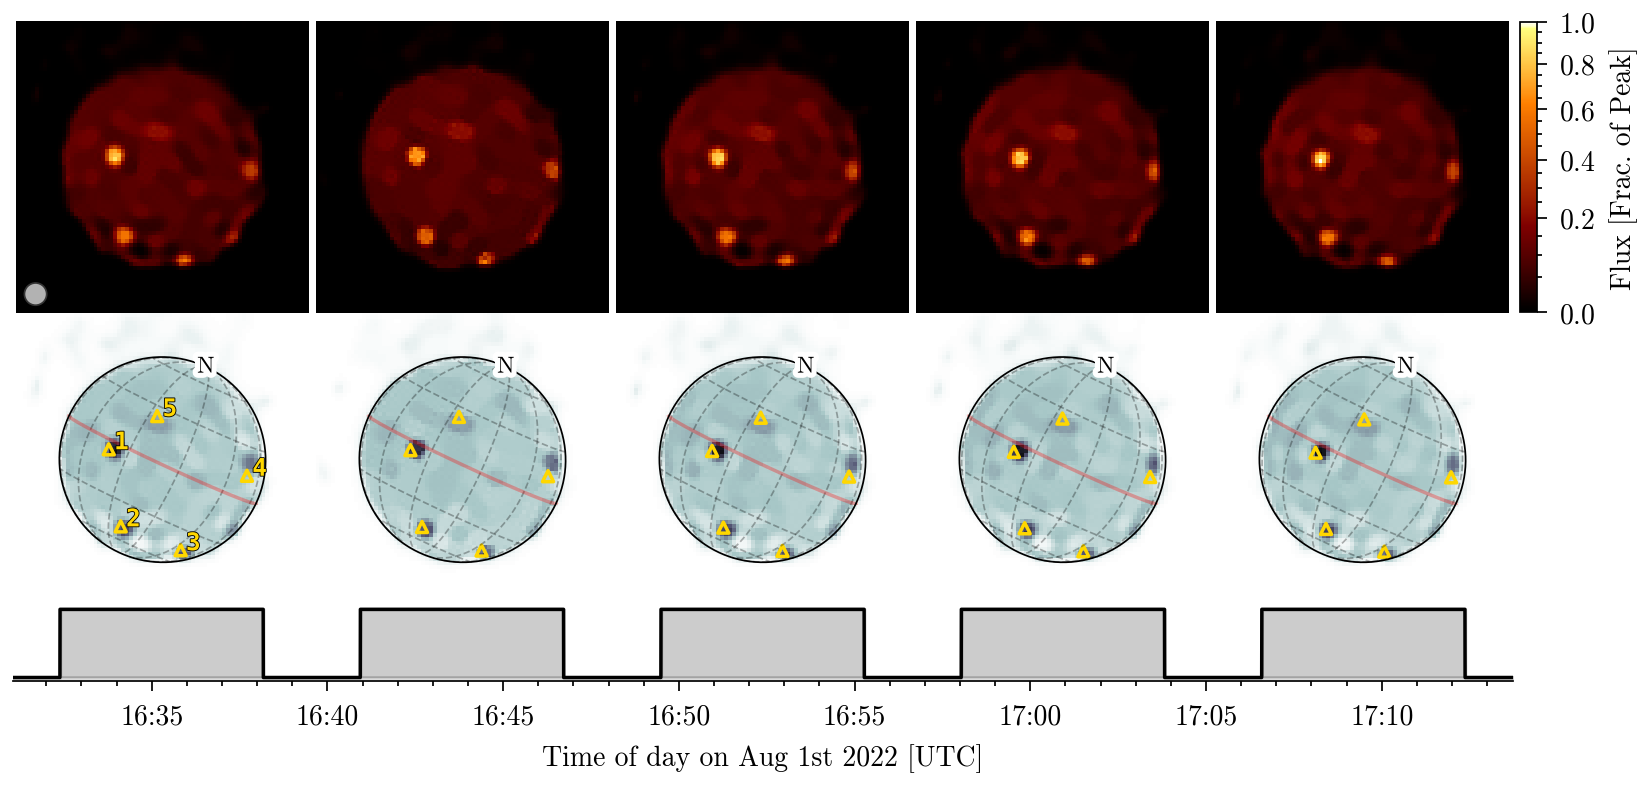

In [34]:
# %matplotlib inline

sci_fits = io_sci_fits
sci_files = io_sci_files

rang, exposings = get_exposing(sci_files, eps=1.35)
exposing = np.sum(exposings, axis=0)

fig, axes = plt.subplots(
    2,
    5,
    figsize=(6, 3),
    gridspec_kw={"hspace": 0.0, "wspace": 0.0, "left": 0, "right": 1.0},
)

# Adjust layout first
# plt.tight_layout()

fig.subplots_adjust(bottom=0.1)  # Shift everything up to leave space for time axis
# fig.subplots_adjust(right=0.9)  # Shift everything up to leave space for time axis

# Create a new axes for the time plot — [left, bottom, width, height] in figure fraction
time_ax = fig.add_axes([0.0, 0.0, 1.0, 0.1])  # Tune values if needed

for col, exp, file in zip(range(len(sci_fits)), sci_fits, sci_files):

    axes[0][col].axis("off")
    axes[1][col].axis("off")

    dist = get_dist(Gpath + "params.npy", "_".join([exp.key, exp.filter]), norm=False)
    dist = dist / io_peak_flux

    # clip_d = np.clip(crop(dist, 80), min=0, max=clip_value)
    clip_d = np.clip(dist, min=clip_value, max=clip_value).at[dist < 0.02].set(0)
    # clip_d = dist
    center = compute_com_physical(
        clip_d,
        pixel_scale,
    )  # + np.array([0.045, 0.005])

    # axes[0][col].set(title=convert_time(time))
    diff_lim = 0.5 * dlu.rad2arcsec(4.3e-6 / optics_diameter) if col == 0 else None
    # ax[0].text(-0.41, 0.67, "4.3μm", fontdict=font_dict)

    c0 = dorito.plotting.plot_result(
        axes[0][col],
        dist,
        pixel_scale=psf_pixel_scale / 3,
        cmap="afmhot_u",
        norm=mpl.colors.PowerNorm(0.7, vmin=0, vmax=1.0),
        translate=-center,
        scale=dist.shape[0] / 75.0,
        diff_lim=diff_lim,
    )

    if col == 4:
        # fig.colorbar(c0, ax=axes[0][col], fraction=0.046, pad=0.04)
        cax = fig.add_axes([1.005, 0.49125, 0.011, 0.387])
        fig.colorbar(c0, cax=cax, label="Flux [Frac. of Peak]")

    c1 = plot_io_with_ephemeris(
        axes[1][col],
        dist,
        pixel_scale=psf_pixel_scale / 3,
        cmap="bone_ur",
        exp=exp,
        data_dir=io_uncal_path,
        norm=mpl.colors.PowerNorm(0.7, vmax=1.0),
        points=list(features.values()),
        # contour=True,
        bg_color="white",
        translate=-center,
        scale=dist.shape[0] / 75.0,
    )

    # Labelling volcanoes
    coords = []
    for artist in axes[1][col].collections:
        if hasattr(artist, "get_offsets"):
            coord = artist.get_offsets()[0]
            coords.append(coord)

    if col == 0:
        eps = 3e-2
        for i, (x, y) in enumerate(coords):  # i should now correctly track the index
            txt = axes[1][col].text(
                x - eps,
                y,
                f"{i+1}",
                fontsize=7,
                c="gold",
                fontfamily="monospace",
                fontweight="bold",
            )  # Use i in the label

            txt.set_path_effects(
                [
                    mpl.patheffects.Stroke(linewidth=0.5, foreground="black"),
                    mpl.patheffects.Normal(),
                ]
            )

time_ax.plot(rang, exposing, "k")
time_ax.fill_between(rang, exposing, color="k", alpha=0.2)
time_ax.spines["top"].set_visible(False)
time_ax.spines["right"].set_visible(False)
time_ax.spines["left"].set_visible(False)
time_ax.tick_params(axis="x", which="both", top=False)
time_ax.set(
    xlim=(rang.min(), rang.max()),
    xlabel="Time of day on Aug 1st 2022 [UTC]",  # Set the x-axis label
    xticks=range(35, 75, 5),
    xticklabels=[
        "16:35",
        "16:40",
        "16:45",
        "16:50",
        "16:55",
        "17:00",
        "17:05",
        "17:10",
    ],
    yticks=[],
)


# time_ax.axis("off")
plt.savefig(f"{save_path}/io/rotation.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [37]:
body = planetmapper.Observation(io_uncal_path + exp.filename + "_uncal.fits")
dir(body)

['FITS_FILE_EXTENSIONS',
 'FITS_KEYWORD',
 '_DEFAULT_DTM_FORMAT_STRING',
 '__class__',
 '__copy__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__replace__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_aberration_correction_encoded',
 '_add_kw_from_header',
 '_add_map_header_metadata',
 '_add_map_wcs_to_header',
 '_add_nans_for_radec_array_wraparounds',
 '_alt_adjustment',
 '_angular2km',
 '_angular2lonlat',
 '_angular2obsvec_norm',
 '_angular2radec',
 '_angular2xy',
 '_assign_radius_values',
 '_auto_load_kernels',
 '_azimuth_angle_from_gie_radians',
 '_cache',
 '_centric2graphic_lonlat',
 '_check_proj_string_for_axis',
 '_clear_cache',
 '_copy_options_to_other',
 '_data_arg',
 '_default_disc_method',

In [42]:
body.get_phase_angle_img?

Signature: body.get_phase_angle_img() -> numpy.ndarray
Docstring:
See also :func:`get_backplane_img`.

Returns:
    :ref:`Read-only array<readonly arrays>` containing the phase angle value of
    each pixel in the image. Points off the disc have a value of NaN.
File:      ~/miniconda3/envs/ami/lib/python3.12/site-packages/planetmapper/body_xy.py
Type:      method

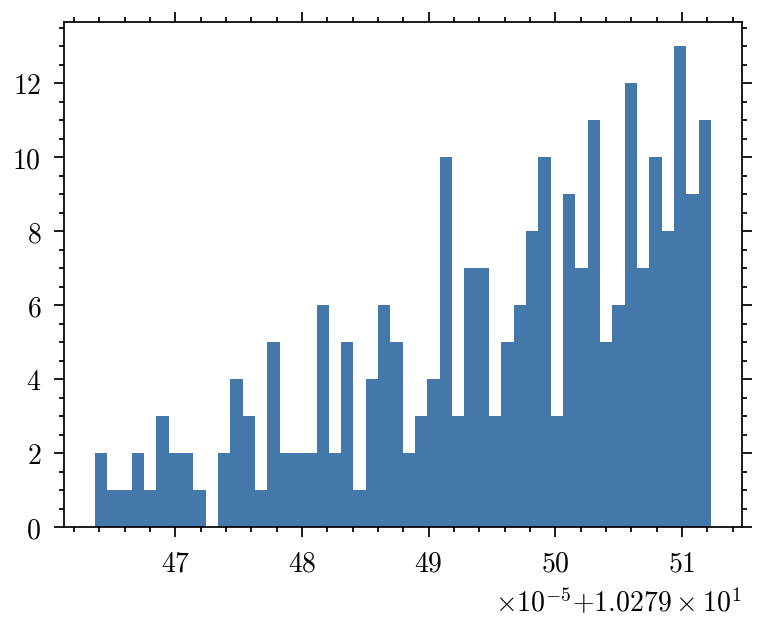

In [47]:
# plt.imshow(body.get_phase_angle_img())
# plt.colorbar()
# plt.show()

plt.hist(body.get_phase_angle_img().ravel(), bins=50)
plt.show()